In [1]:
# !pip install -qq -U hvplot
# import hvplot.pandas
# hvplot.extension('matplotlib')

## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

# if torch.cuda.is_available():
#     get_ipython().run_line_magic('load_ext', 'cudf.pandas')
#     get_ipython().run_line_magic('load_ext', 'cuml.accel')
#     from cuml.preprocessing import TargetEncoder as cuTE

ℹ️ Running on Cuda: False


In [2]:
try:
    import xgboost as xgb
except:
    %pip install -q -U xgboost
    import xgboost as xgb

try:
    import lightgbm as lgb
except:
    %pip install -q -U lightgbm
    import lightgbm as lgb

try:
    import catboost as cgb
except:
    %pip install -q -U catboost
    import catboost as cgb

In [3]:
print(f"xgboost  version: {xgb.__version__}")
print(f"lightgbm version: {lgb.__version__}")
print(f"catboost version: {cgb.__version__}")

xgboost  version: 3.2.0
lightgbm version: 4.6.0
catboost version: 1.2.10


In [4]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

## -- Functional Tools --
from time import time, sleep
from tqdm.auto import tqdm
import itertools
from scipy.optimize import minimize

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, RidgeCV

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e6/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
# orig = orig.loc[:, train.columns]

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total Numerical: 8
Total Categorical: 2
Total base features: 10


In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is unique: {train.id.is_unique}")
# print(f"Test  ID column is unique: {test.id.is_unique}")

In [8]:
display(train.head())
# train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


In [9]:
train.nunique()

alpha                439819
delta                444062
u                    577347
g                    577347
r                    577347
i                    577347
z                    577347
redshift             573975
spectral_type             4
galaxy_population         2
class                     3
dtype: int64

In [10]:
train.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780
class,577347.0,0.489465,0.732431,0.000000,0.000000,0.000000,1.000000,2.000000


In [11]:
train.describe(exclude='number').T

,count,unique,top,freq
spectral_type,577347,4,M,303323
galaxy_population,577347,2,Red_Sequence,319565


In [12]:
display(test.head())
test.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              247435 non-null  float64
 1   delta              247435 non-null  float64
 2   u                  247435 non-null  float64
 3   g                  247435 non-null  float64
 4   r                  247435 non-null  float64
 5   i                  247435 non-null  float64
 6   z                  247435 non-null  float64
 7   redshift           247435 non-null  float64
 8   spectral_type      247435 non-null  object 
 9   galaxy_population  247435 non-null  object 
dtypes: float64(8), object(2)
memory usage: 18.9+ MB


In [13]:
display(orig.head())
orig.info()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  int64  
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(8)


In [14]:
orig.nunique()

obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64

In [15]:
# Check if column names are the same regardless of order
are_same_set = set(train.columns) == set(orig.columns)
print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# Check if column names are the same and in the same order
are_same_exact = train.columns.equals(orig.columns)
print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

Are column names the same regardless of order (train vs orig)? False
Are column names exactly the same and in the same order (train vs orig)? False


In [16]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [
            pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
             # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
             pd.DataFrame(TEST_UNIQUE, index=['Test']),
        ],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


In [17]:
# !rm -r /kaggle/working

### YDATA-PROFILE REPORT

In [18]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

In [19]:
# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# t='train_'
# o='original_'
# te='test_'

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title=t, explorative=True)
# # test_report = ProfileReport(test, title=te, explorative=True)
# orig_report = ProfileReport(orig, title=o, explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file(f"{TARGET} | {t}{o}_stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

In [20]:
# ## -- PLOT TARGET DISTRIBUTION --
# # plt.figure(figsize=(16, 6))
# _, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

# ## -- KDEs --
# sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
# sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
# axs[0].legend()
# axs[0].set_xlabel('')

# # Boxplots
# # pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
# #     widths=0.6,
# #     showmeans=True,
# #     # meanline=True,
# #     # patch_artist=True,
# #     # notch=True,
# #     # labels=['Train', 'Original'],
# #     ax=axs[1])

# sns.violinplot(
#     data=[train[TARGET].values, orig[TARGET].values],
#     inner='quart',
#     width=0.6,
#     # size=1,
#     # width=0.6,
#     # linewidth=2,
#     # fliersize=.1,
#     ax=axs[1],
#     palette=PALETTE)

# axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

# plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [21]:
def distplots_data(train: pd.DataFrame, test: pd.DataFrame, orig: pd.DataFrame, features: list[str]):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            orig[features].assign(Source='Original')
    ], ignore_index=True)
    
    for i, col in enumerate(features):
        _, axs = plt.subplots(
            1, 2,
            figsize=(18, 5),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]}
        )
        ## -- KDE plots --
        sns.kdeplot(data=train, x=col, linewidth=2, ax=axs[0], label='Train')
        sns.kdeplot(data=test, x=col, linewidth=2, ax=axs[0], label='Test')
        sns.kdeplot(data=orig, x=col, linewidth=2, ax=axs[0], label='Orig')
        axs[0].set_title(f'\n{col}', fontdict={'size': 15, 'weight': 'bold'})
        axs[0].set(xlabel='')
        axs[0].legend()

        ## -- BOX plots --
        sns.boxplot(
            data=df,
            y=col,
            x='Source',
            width=0.5,
            linewidth=2,
            ax=axs[1],
            palette=PALETTE
        )
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

    plt.tight_layout()
    plt.show()

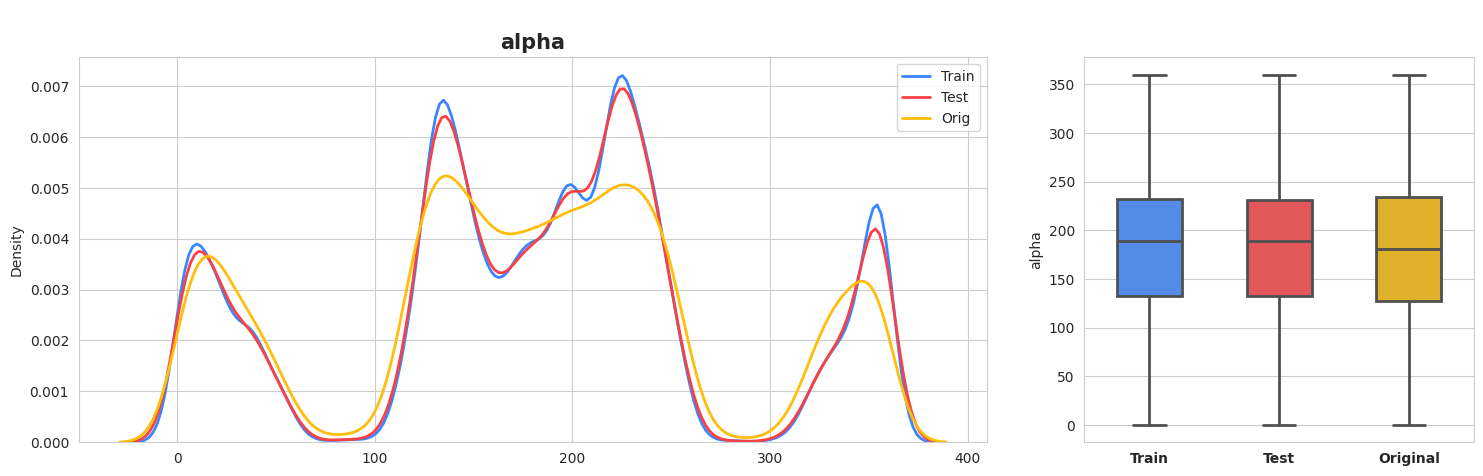

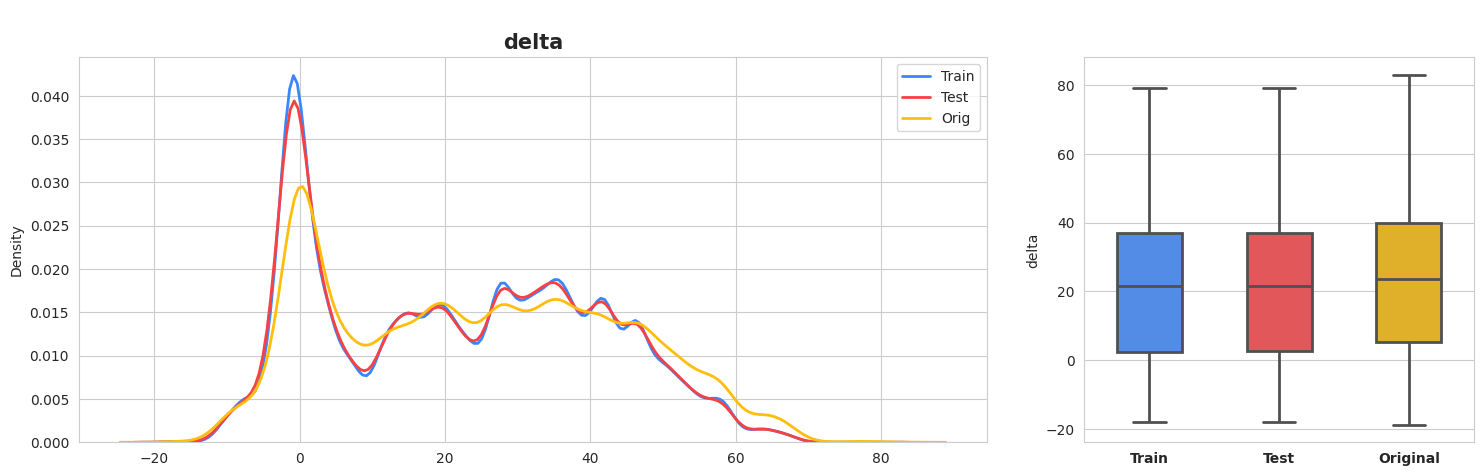

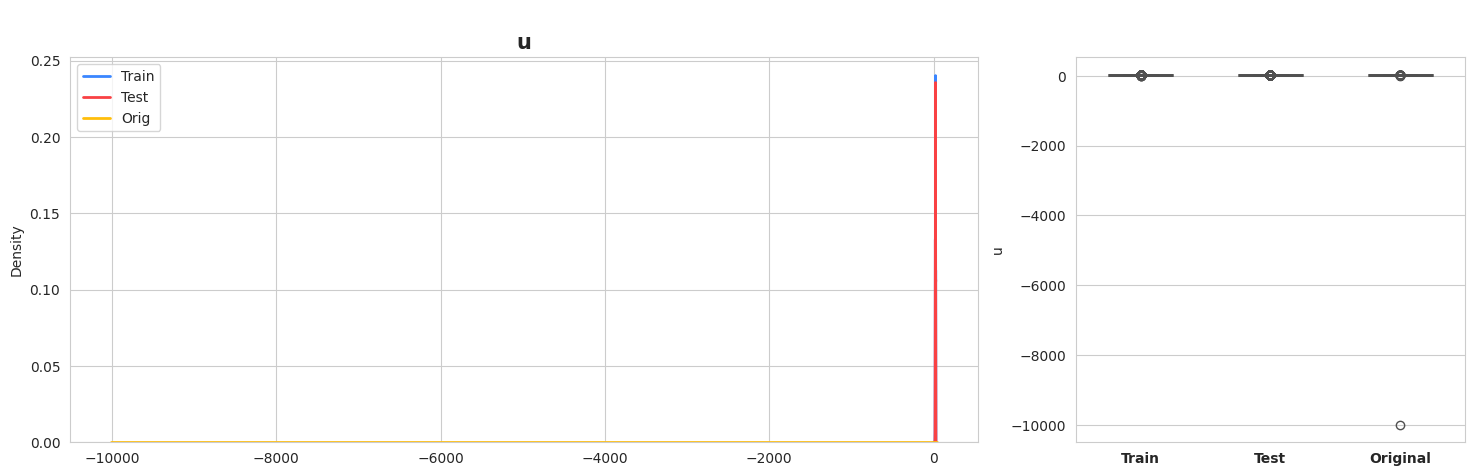

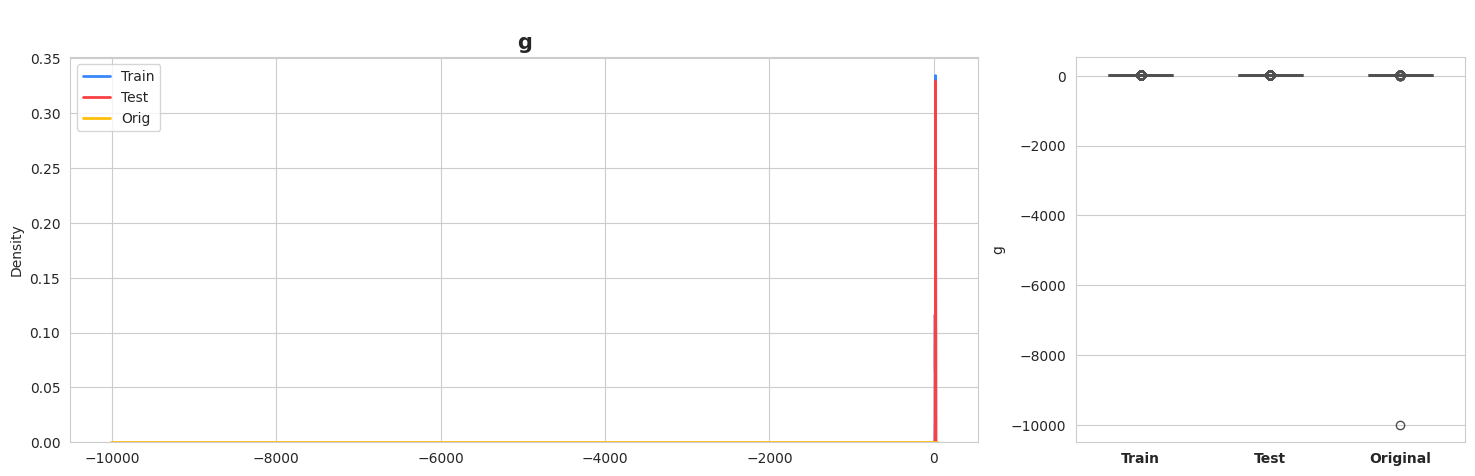

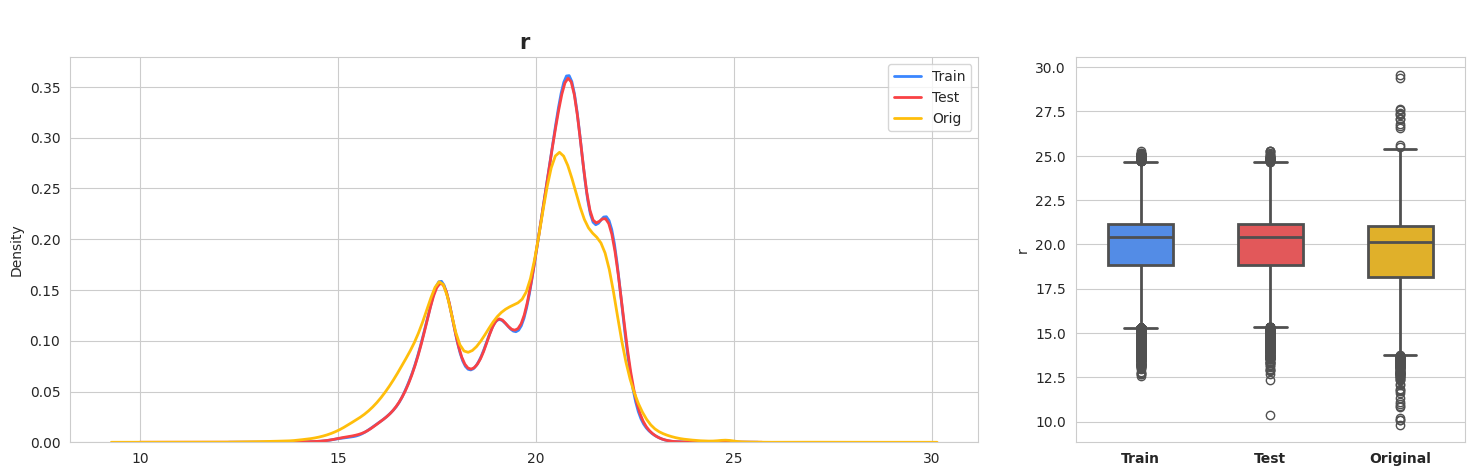

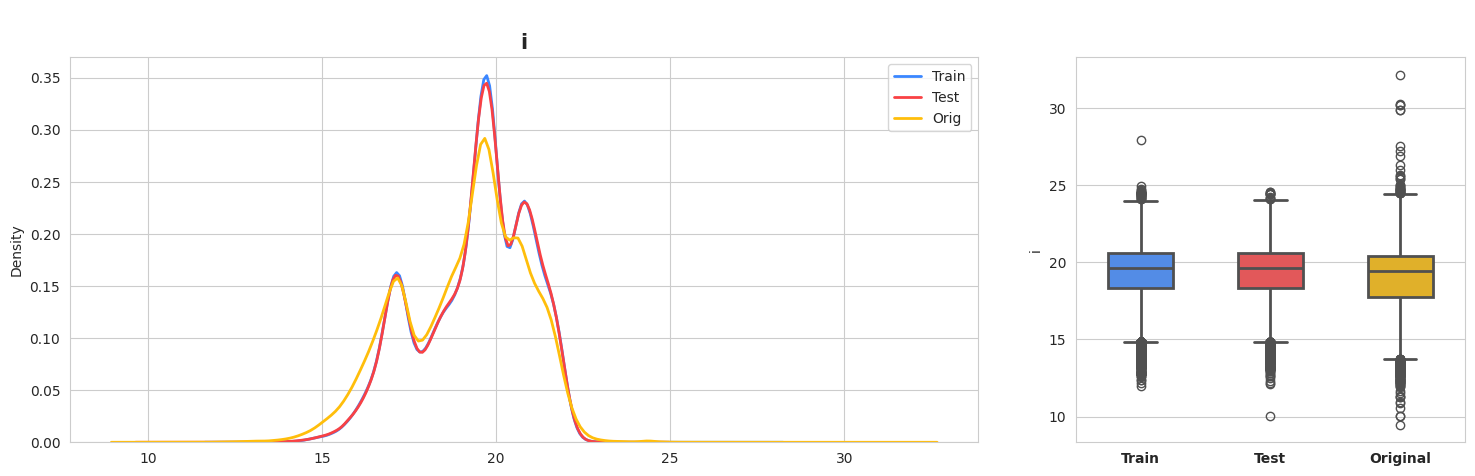

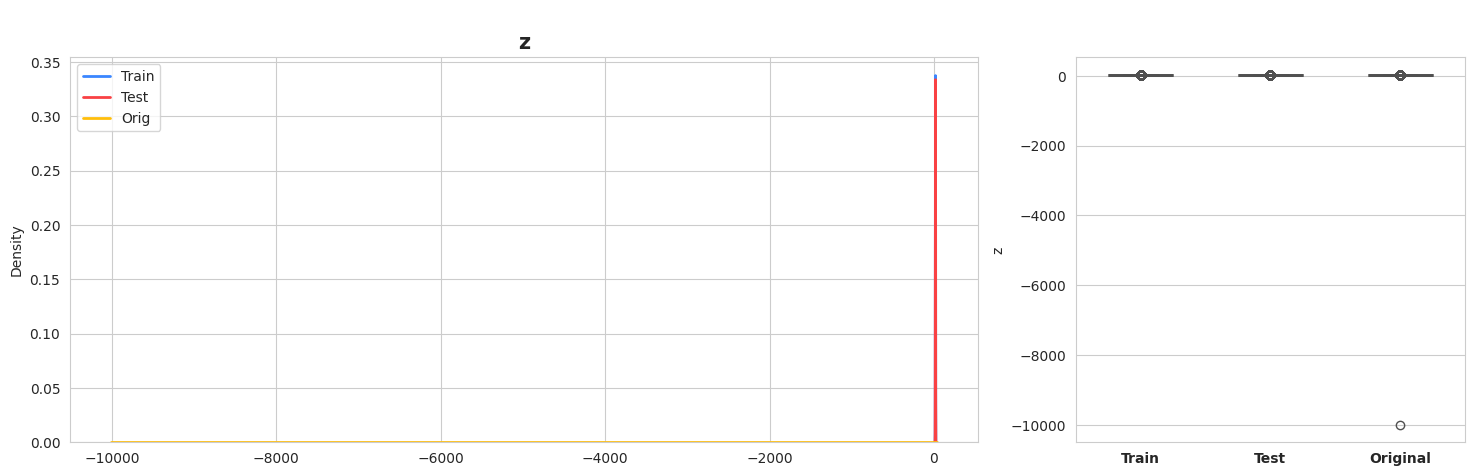

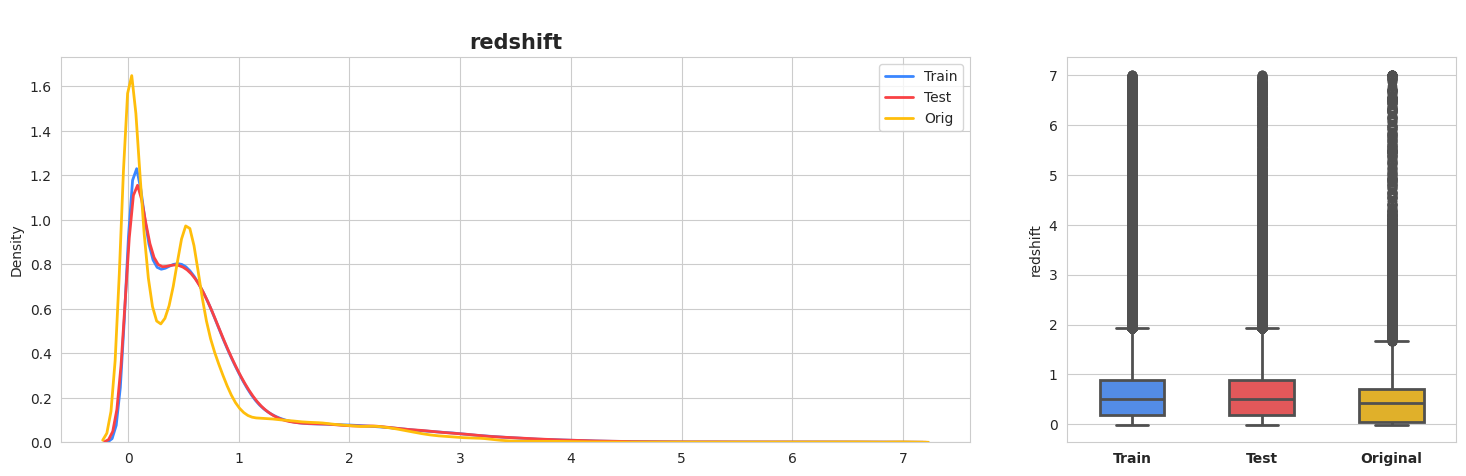

In [22]:
distplots_data(train, test, orig, NUMS)

## ~ CATEGORICAL

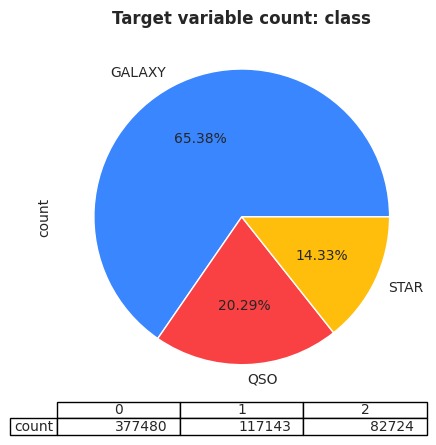

In [23]:
## -- TARGET counts --
train[TARGET].value_counts(dropna=False).plot.pie(autopct='%1.2f%%', table=True, labels=mapping.keys())
plt.title(f"Target variable count: {TARGET}", fontweight='semibold')
plt.show()

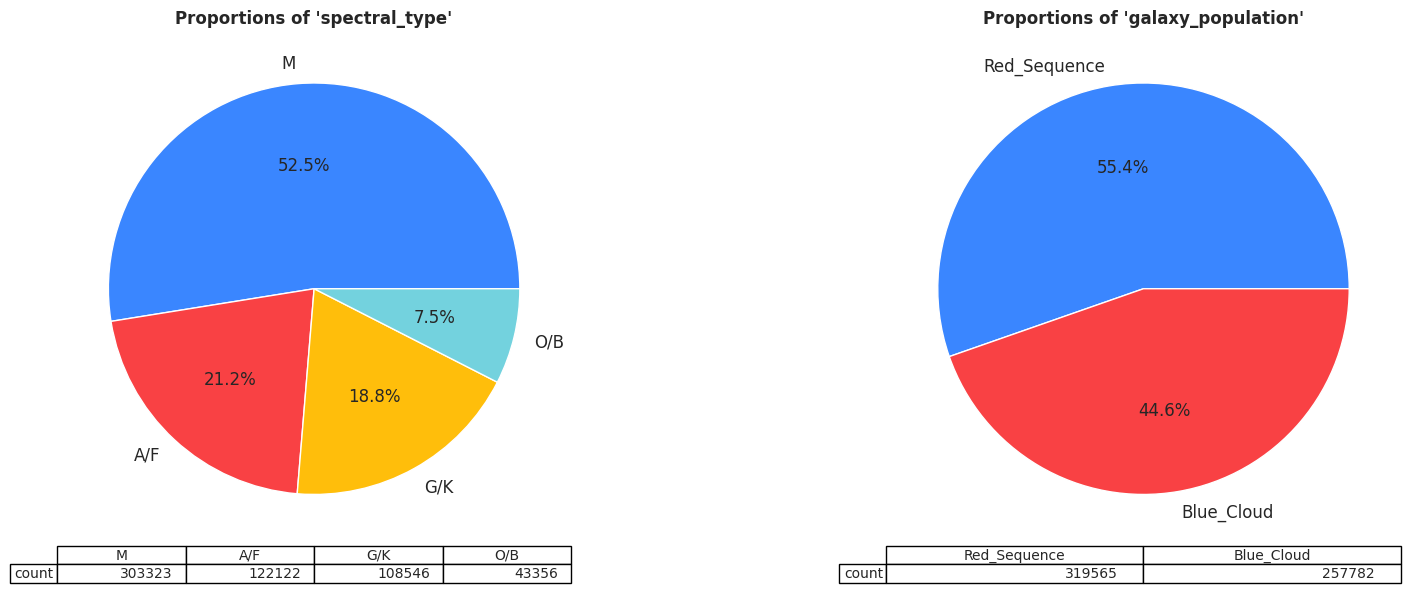

In [24]:
## -- Categorical Features --
plt.figure(figsize=(18, 6))

for i, col in enumerate(CATS):
    plt.subplot(1, 2, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.1f%%', fontsize=12, table=True)
    plt.title(f"Proportions of '{col}'", fontdict={'size':12, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout(h_pad=2.0, w_pad=1.0)
plt.show()

In [25]:
train

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0
...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,0
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,0
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,0
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,1


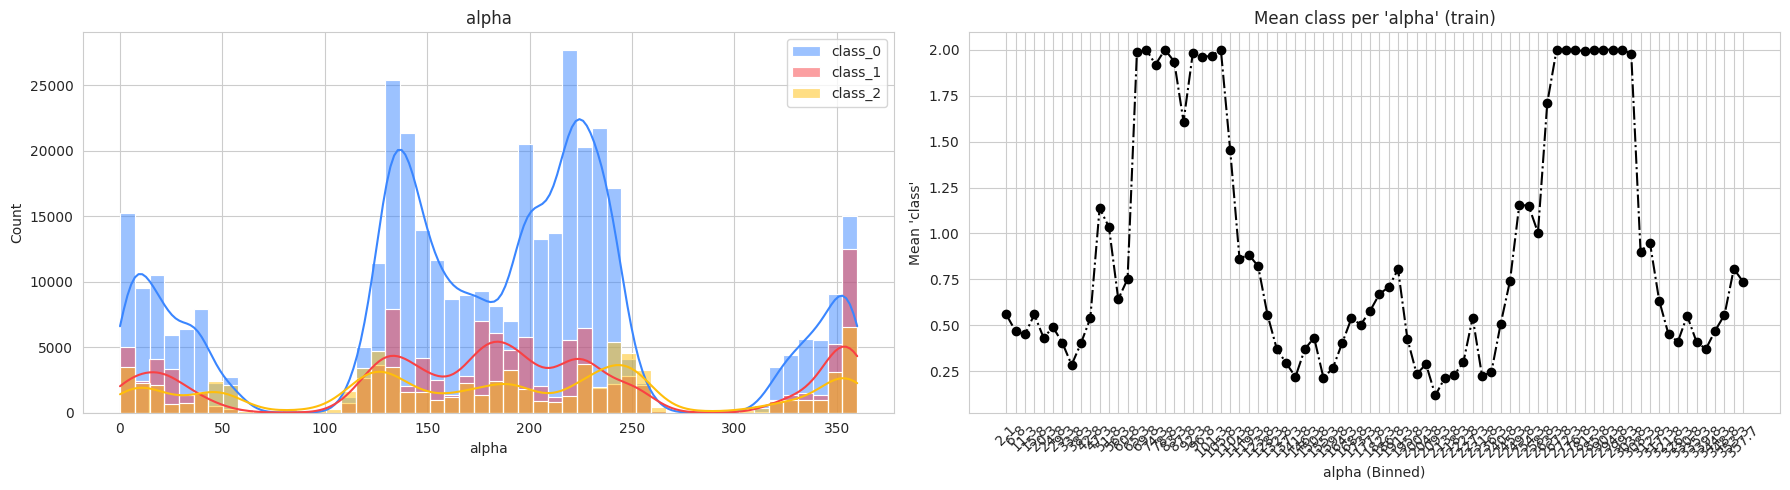

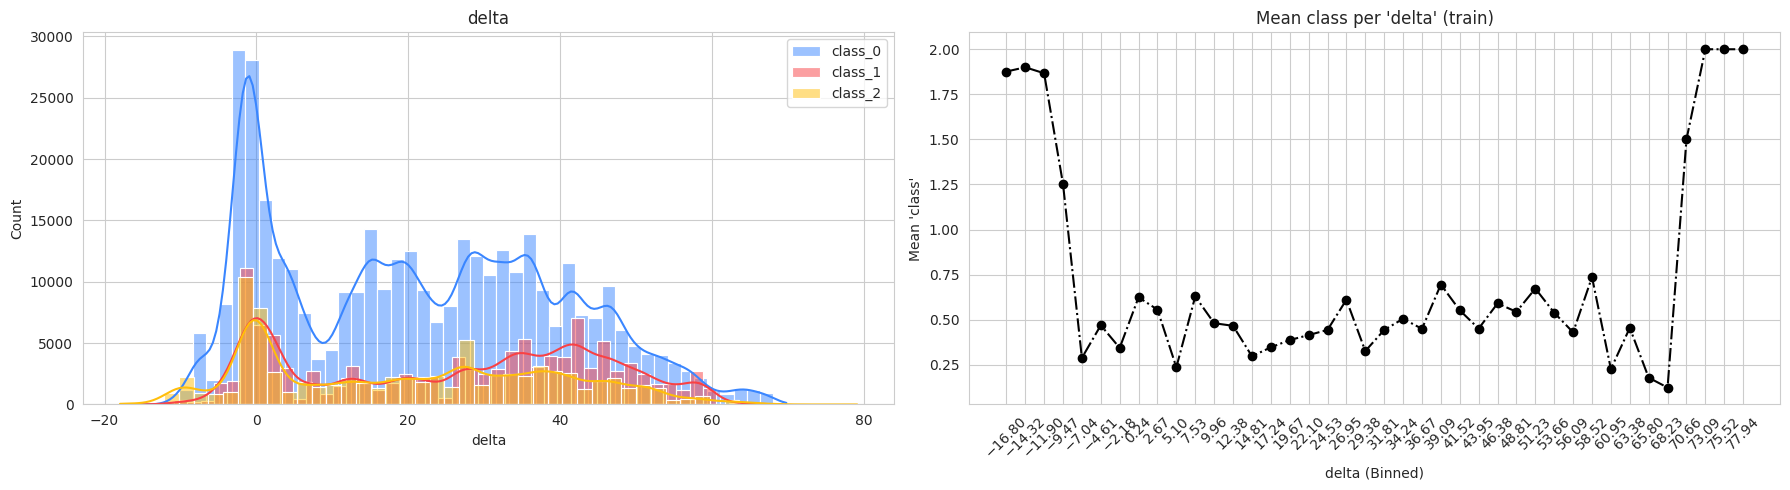

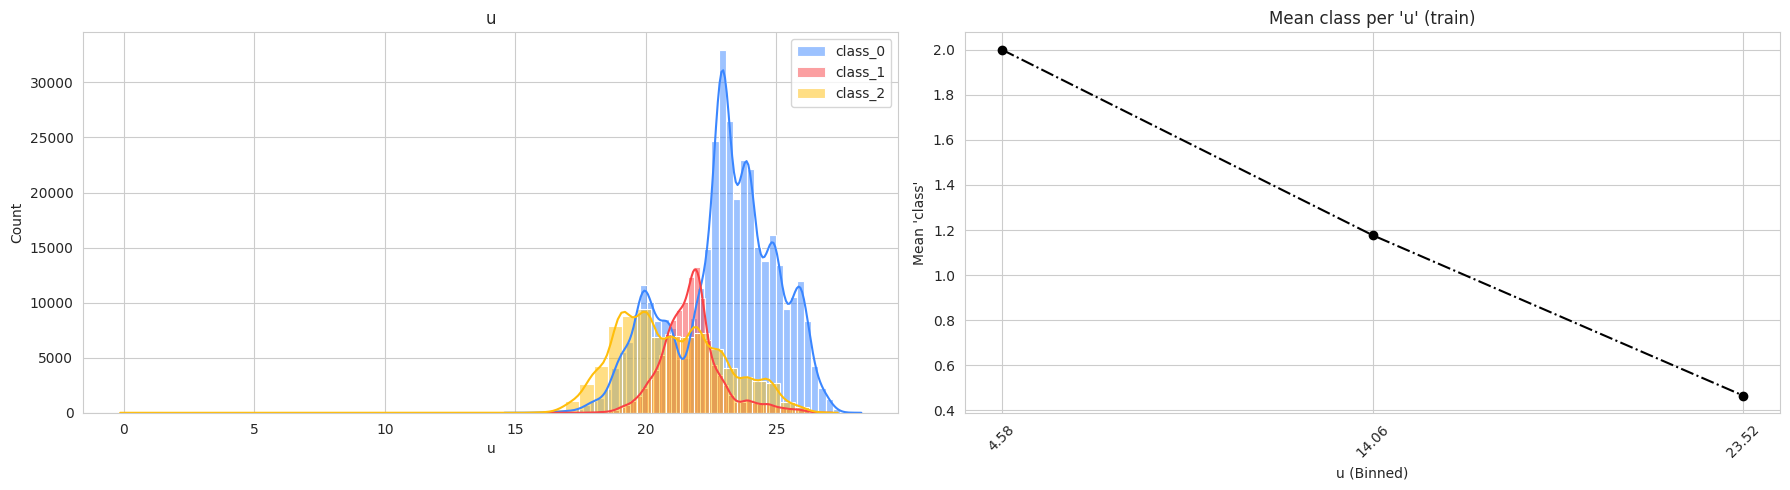

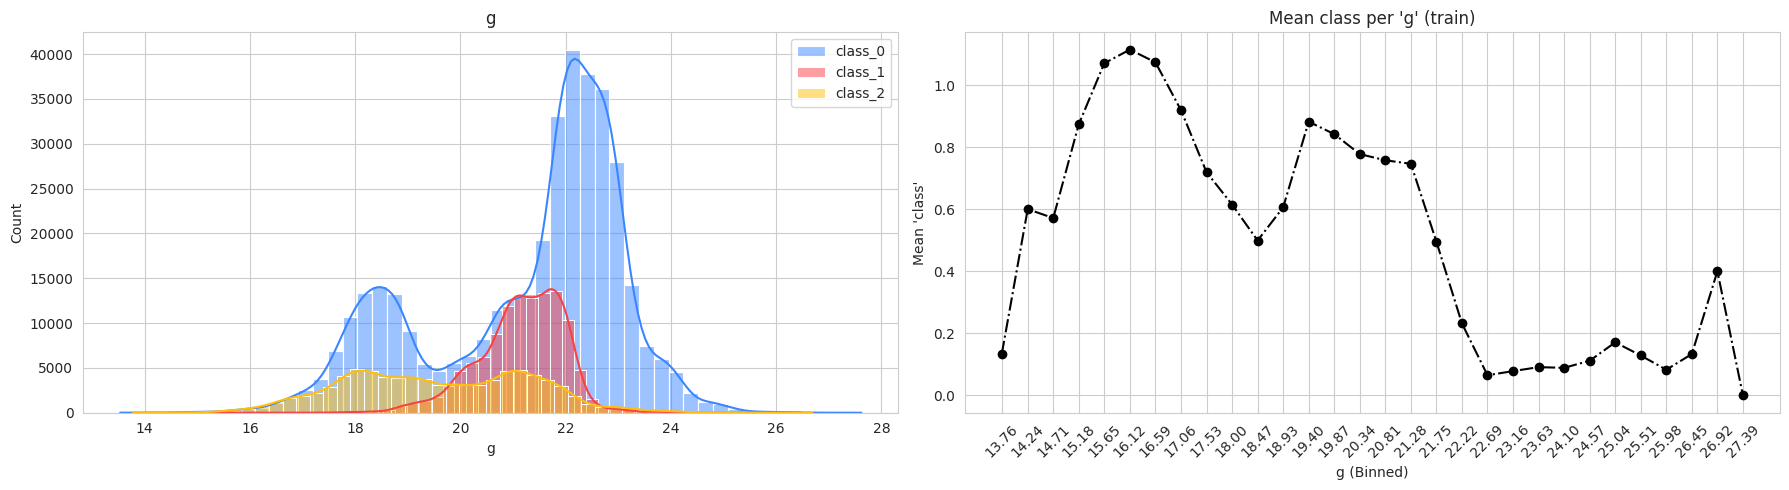

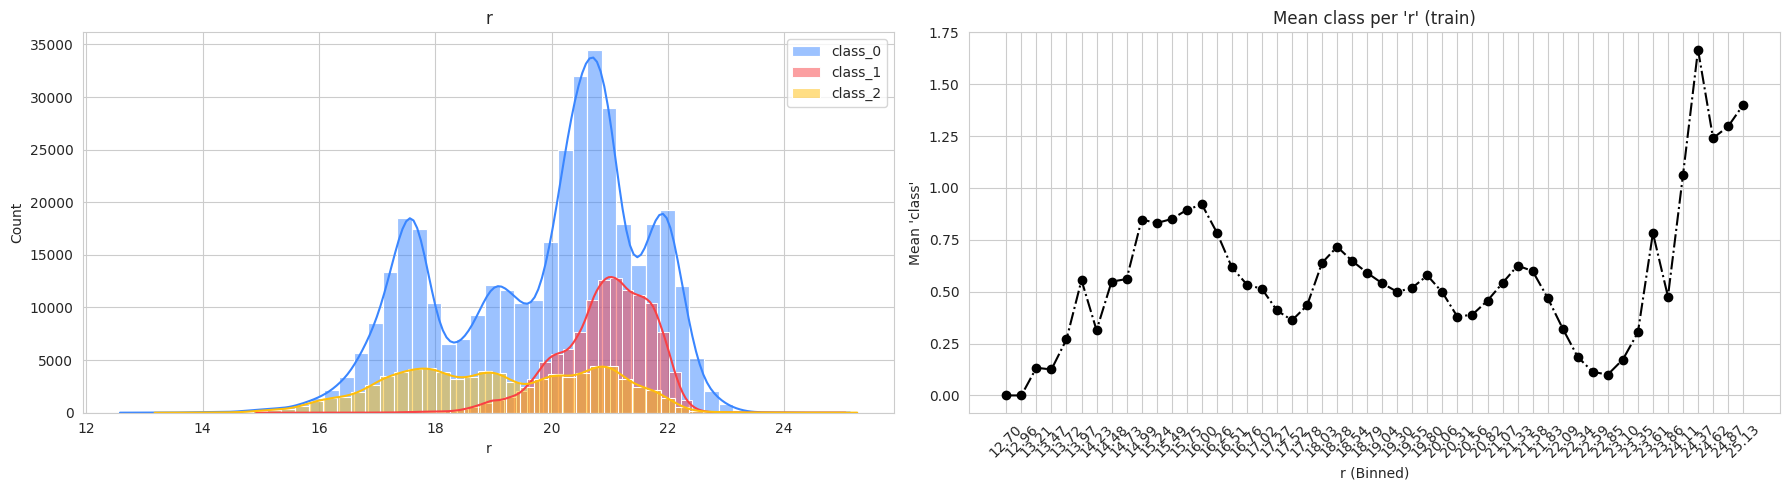

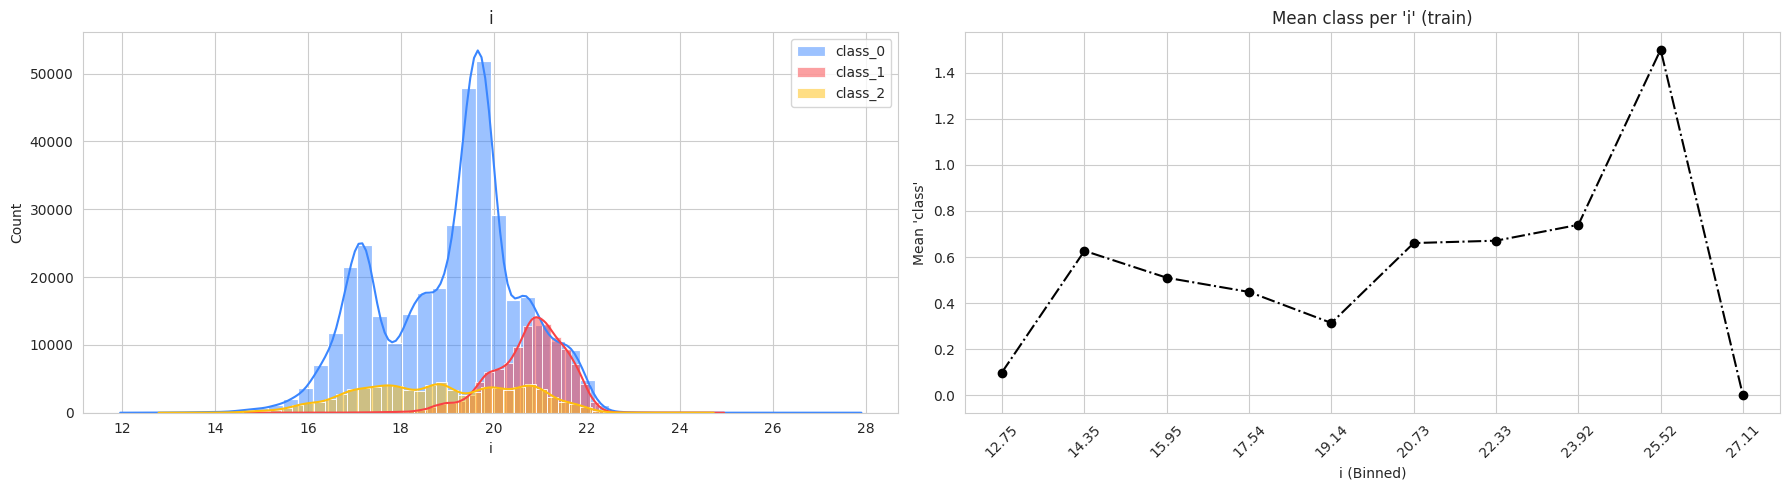

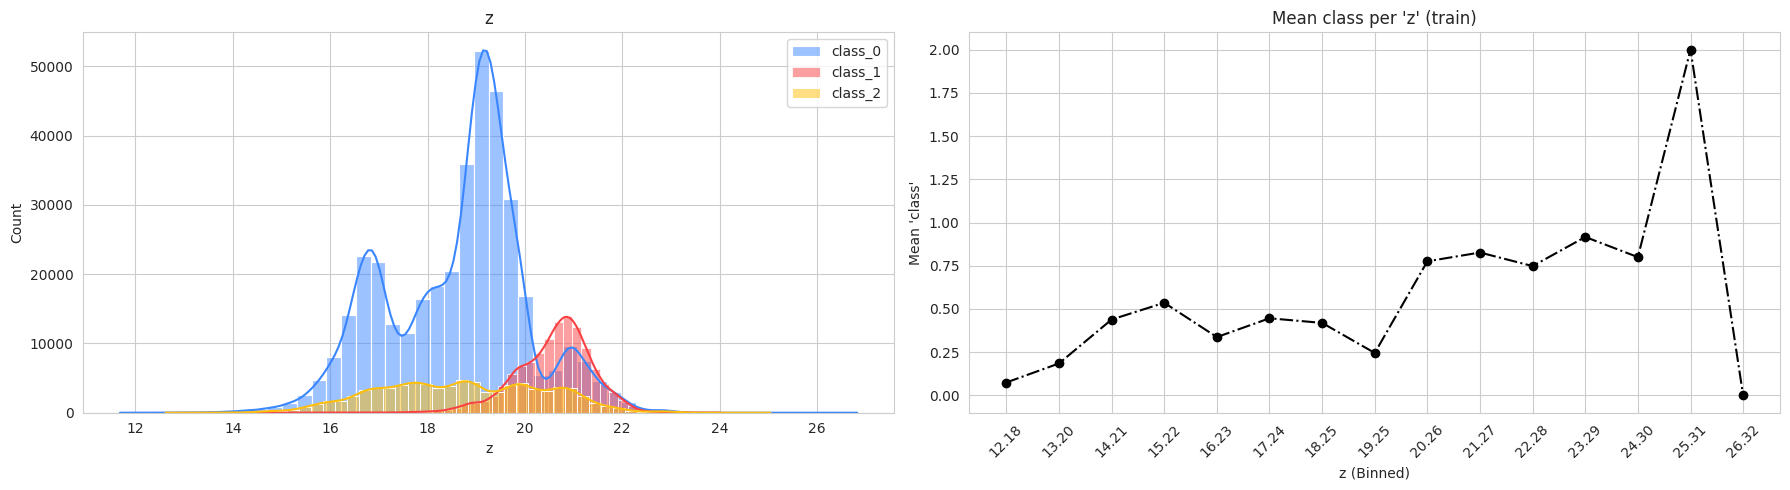

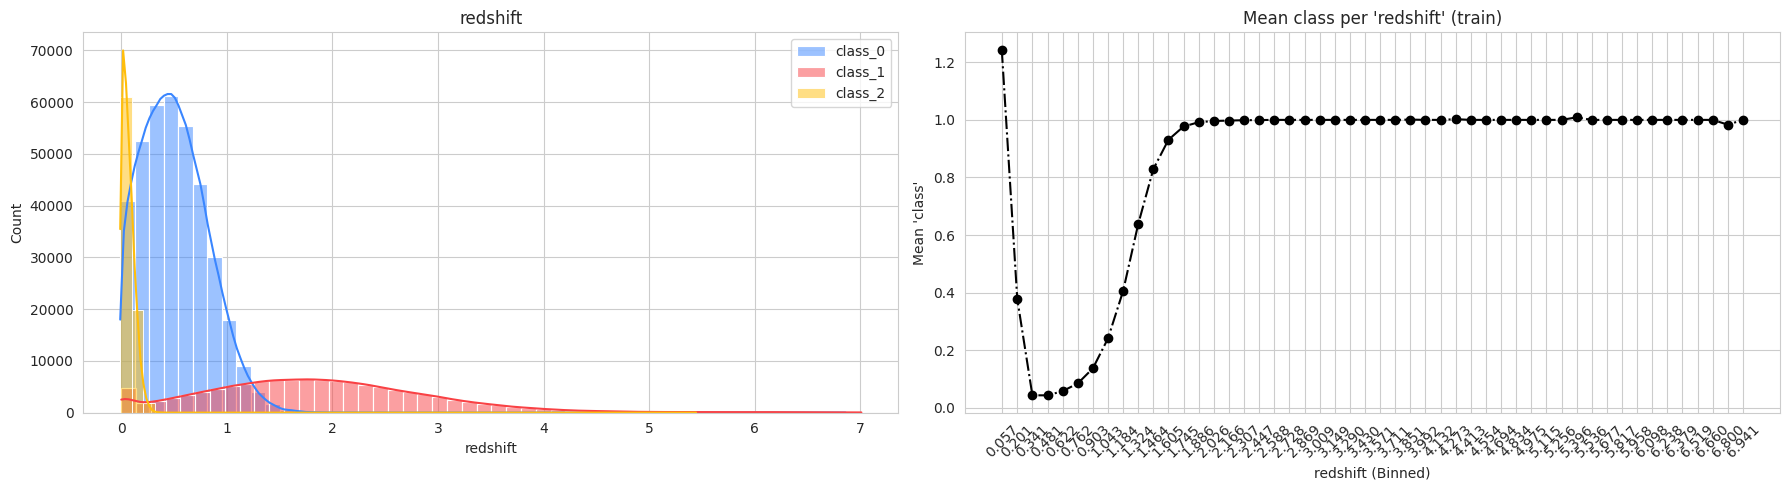

In [26]:
BINS = 80
BIN_COLS = ['alpha', 'delta', 'redshift', 'r', 'i']

for c in NUMS:
    if c =='alpha':
        BINS = 80
    elif c == 'delta':
        BINS = 40
    elif c == 'redshift':
        BINS = 50
    elif c == 'r':
        BINS = 50
    elif c == 'i':
        BINS = 10
    elif c == 'u':
        BINS = 3
    elif c == 'g':
        BINS = 30
    elif c == 'z':
        BINS = 15
    # PLOT TRAIN DISTRIBUTION COMPARED WITH TEST DISTRIBUTION
    plt.figure(figsize=(18, 5))
    plt.subplot(121)
    # sns.histplot(train[c],kde=True,bins=50,label='train')
    # sns.histplot(test[c],kde=True,bins=50,label='test')
    sns.histplot(train[train[TARGET]==0][c],kde=True,bins=50,label='class_0',)
    sns.histplot(train[train[TARGET]==1][c],kde=True,bins=50,label='class_1',)
    sns.histplot(train[train[TARGET]==2][c],kde=True,bins=50,label='class_2',)
    plt.legend()
    plt.title(f"{c}")

    # PLOT TARGET RELATIONSHIP WITH BINNED BASE
    plt.subplot(122)
    train['bucket'], edges = pd.cut(train[c],bins=BINS,include_lowest=True,retbins=True,labels=False)
    bucket_means = train.groupby('bucket')[TARGET].mean()
    bin_midpoints = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_midpoints, bucket_means, marker='o',linestyle='-.',color='k')
    plt.xlabel(f'{c} (Binned)')
    plt.ylabel(f"Mean '{TARGET}'")
    plt.title(f"Mean {TARGET} per '{c}' (train)")
    plt.xticks(bin_midpoints, rotation=45)

    plt.tight_layout()
    plt.show()

train = train.drop(columns=['bucket'])

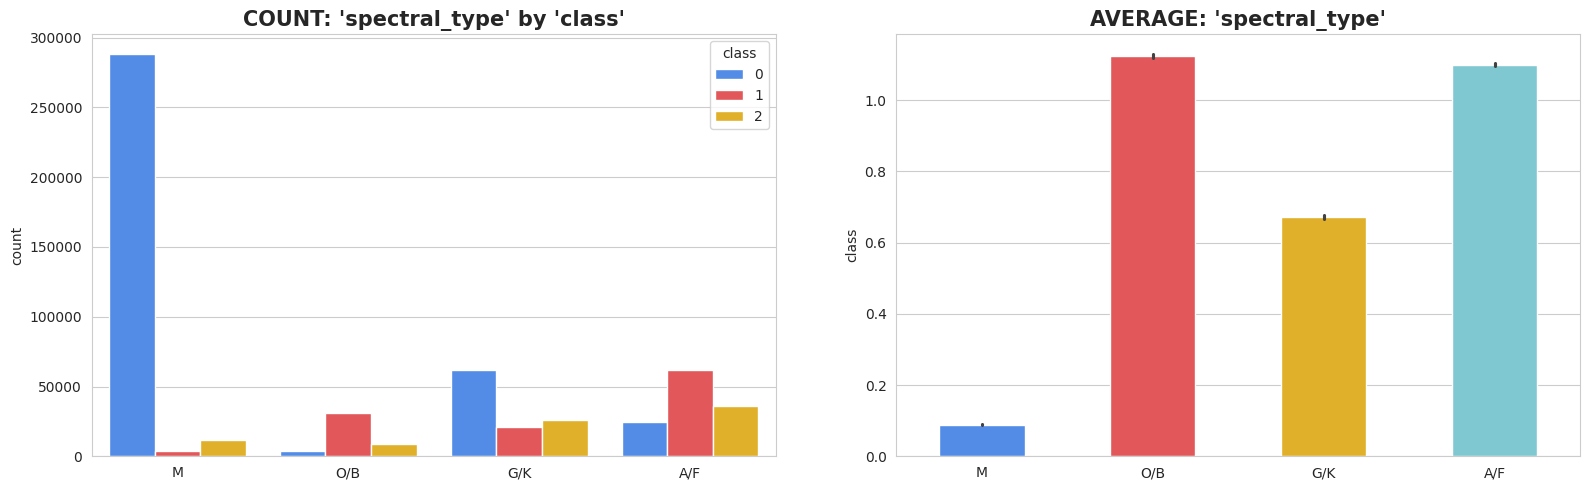

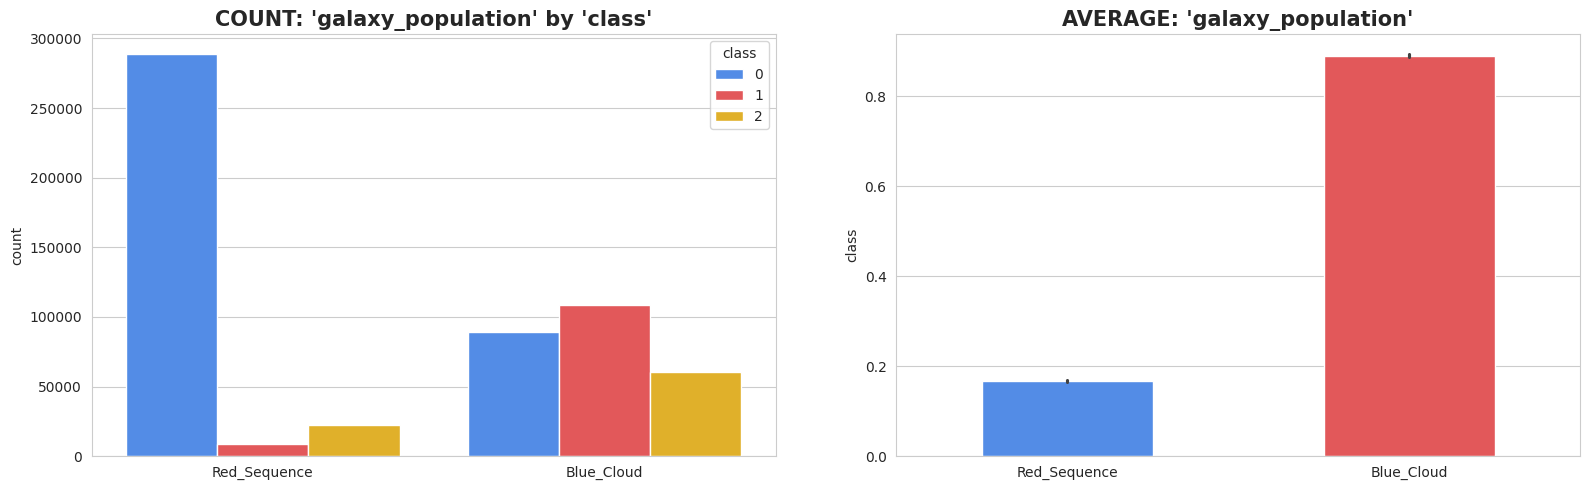

In [27]:
## -- Categorical Features: Counts and Mean by TARGET --
for i, c in enumerate(CATS):
    plt.figure(figsize=(16, 5))

    plt.subplot(121)
    sns.countplot(train, x=c, hue=TARGET, palette=PALETTE)
    plt.title(f"COUNT: '{c}' by '{TARGET}'", fontdict={'size': 15, 'weight': 'semibold'})
    plt.xlabel('')

    plt.subplot(122)
    sns.barplot(train, x=c, y=TARGET, estimator='mean', width=0.5, palette=PALETTE)
    plt.title(f"AVERAGE: '{c}'", fontdict={'size': 15, 'weight': 'semibold'})
    plt.xticks(rotation=0)
    plt.xlabel('')
    
    plt.tight_layout(w_pad=5.0)
    plt.show()
    print()

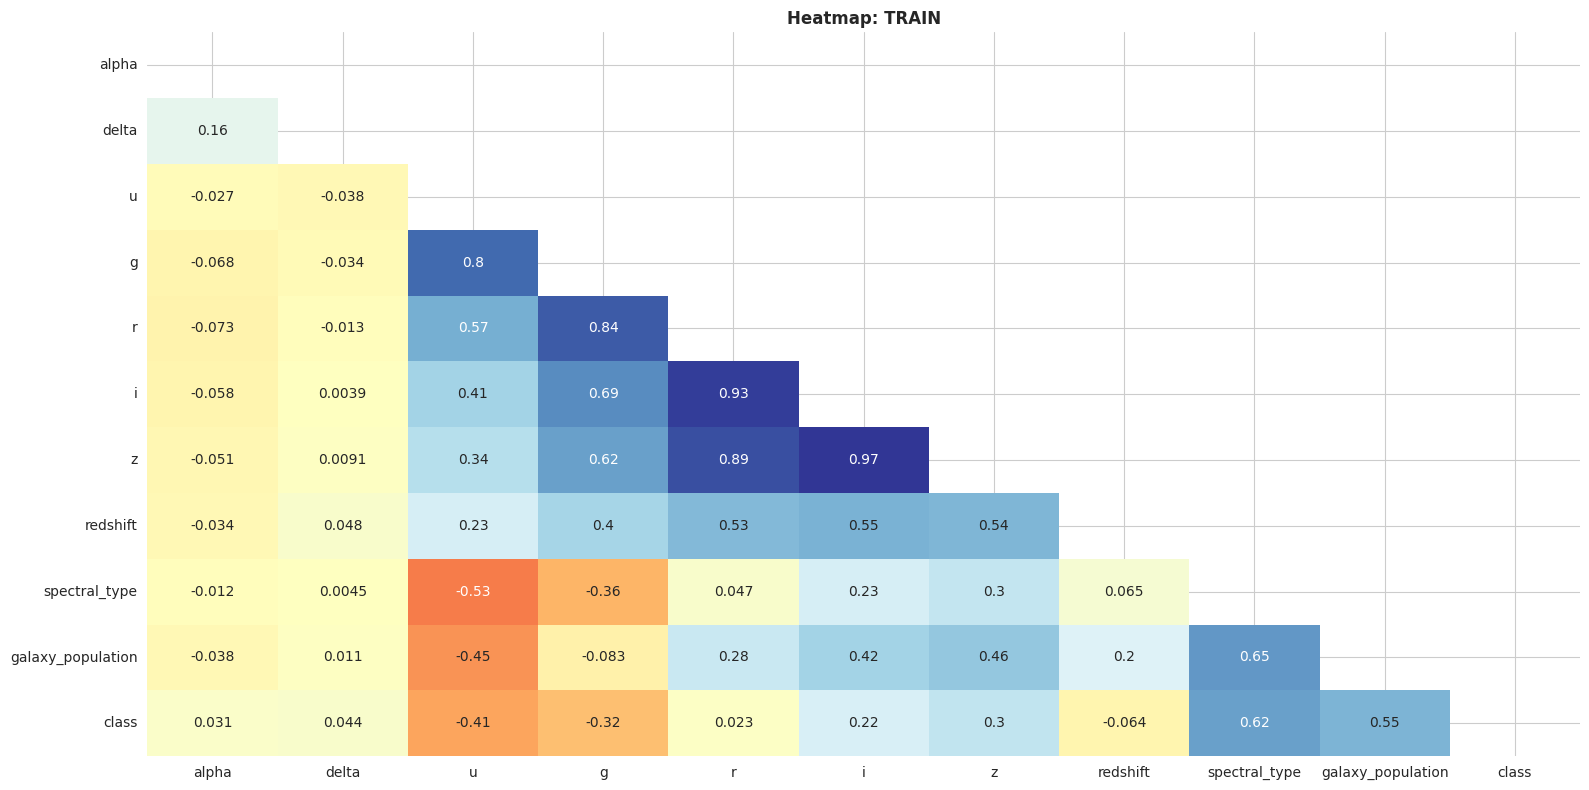

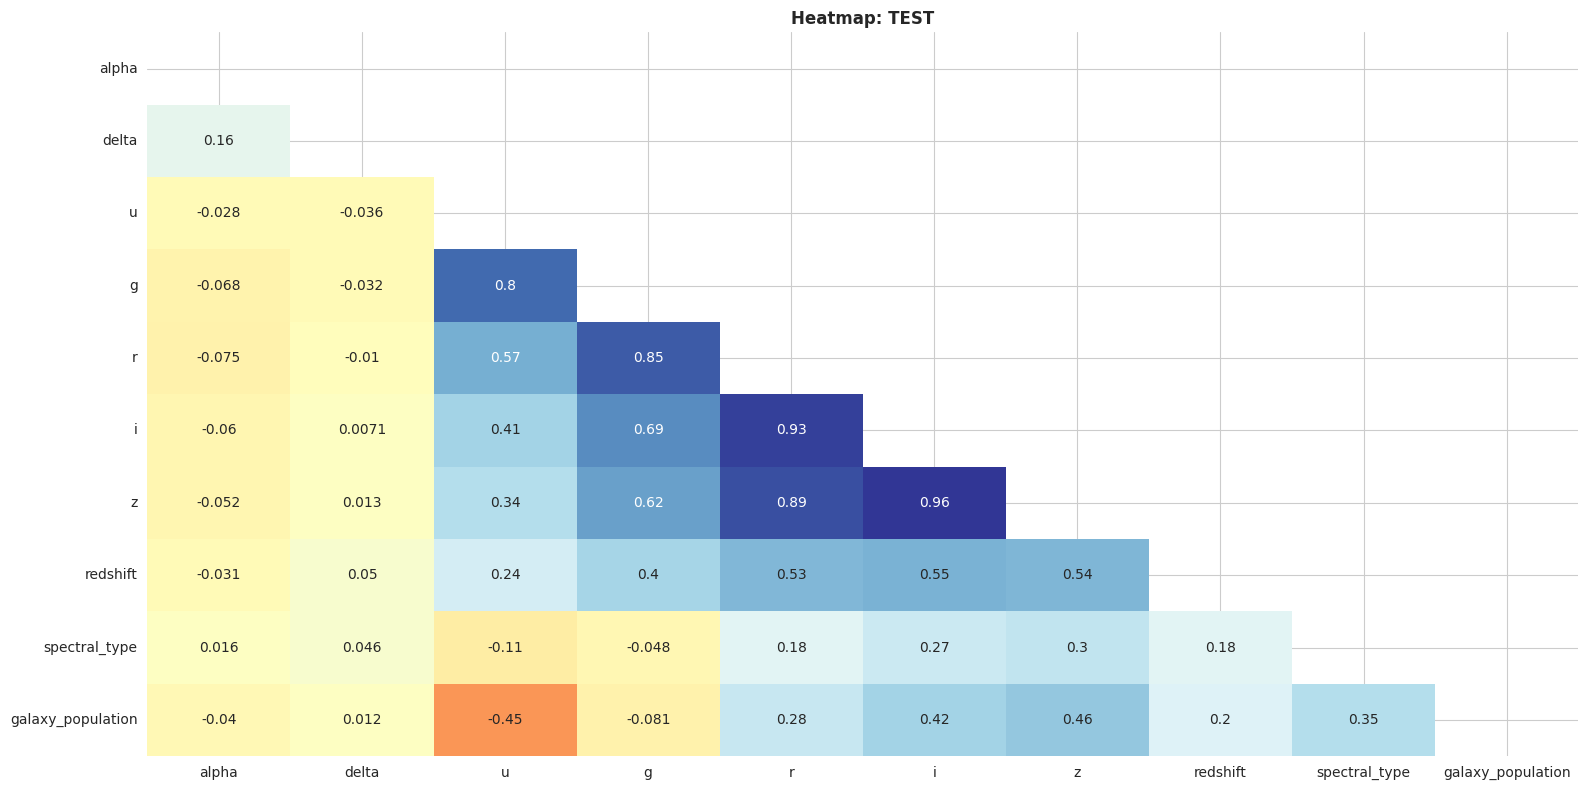

In [28]:
def plot_heatmap(data, cat_features, name='Data'):
    df = data.copy()
    for c in cat_features:
        if df[c].dtype in ['object', 'category']:
            df[c] = pd.factorize(df[c])[0]

    CORR = df.corr('spearman')
    plt.figure(figsize=(16, 8))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cmap='RdYlBu', cbar=False, center=0)
    plt.title(f"Heatmap: {name}", fontdict={'size':12, 'weight': 'semibold'})
    plt.tight_layout()
    plt.show()

    del df

plot_heatmap(train, CATS, 'TRAIN')
# plot_heatmap(orig, CATS, 'ORIGINAL')
plot_heatmap(test, CATS, 'TEST')

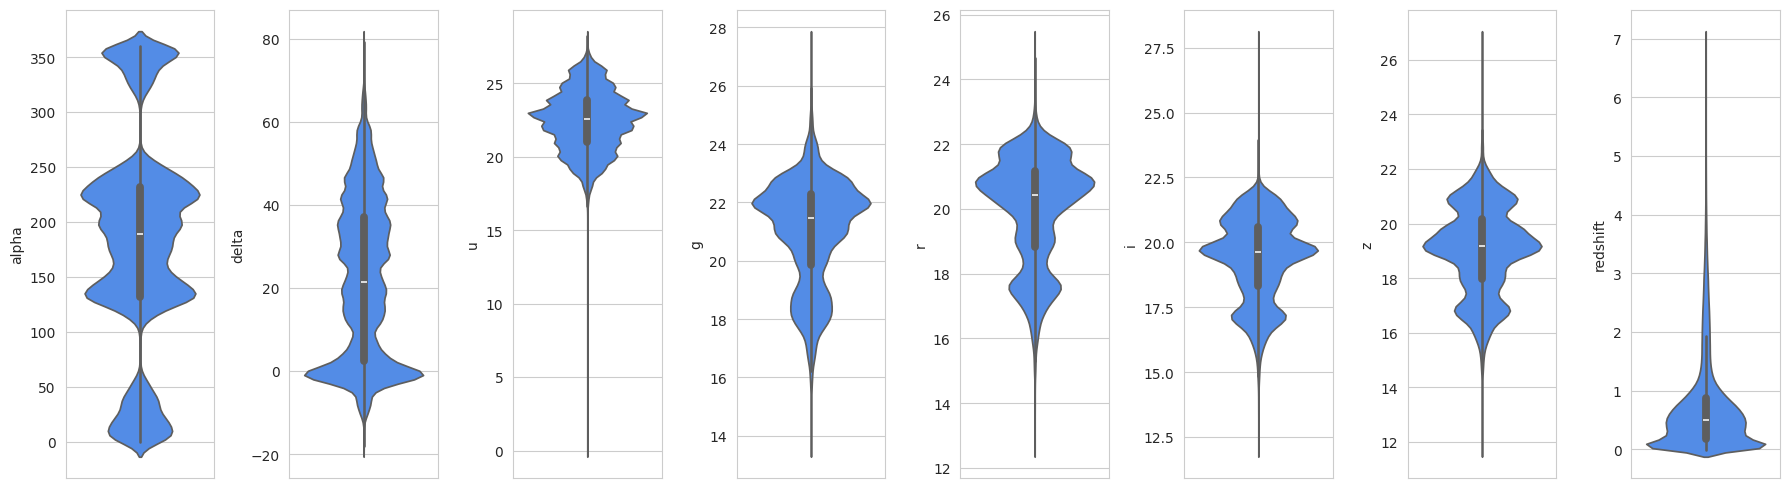

In [29]:
## -- VIOLIN PLOT --
plt.figure(figsize=(18, 5))

for i, col in enumerate(NUMS):
    plt.subplot(1, len(NUMS), i+1)
    sns.violinplot(train[col])

plt.tight_layout()
plt.show()

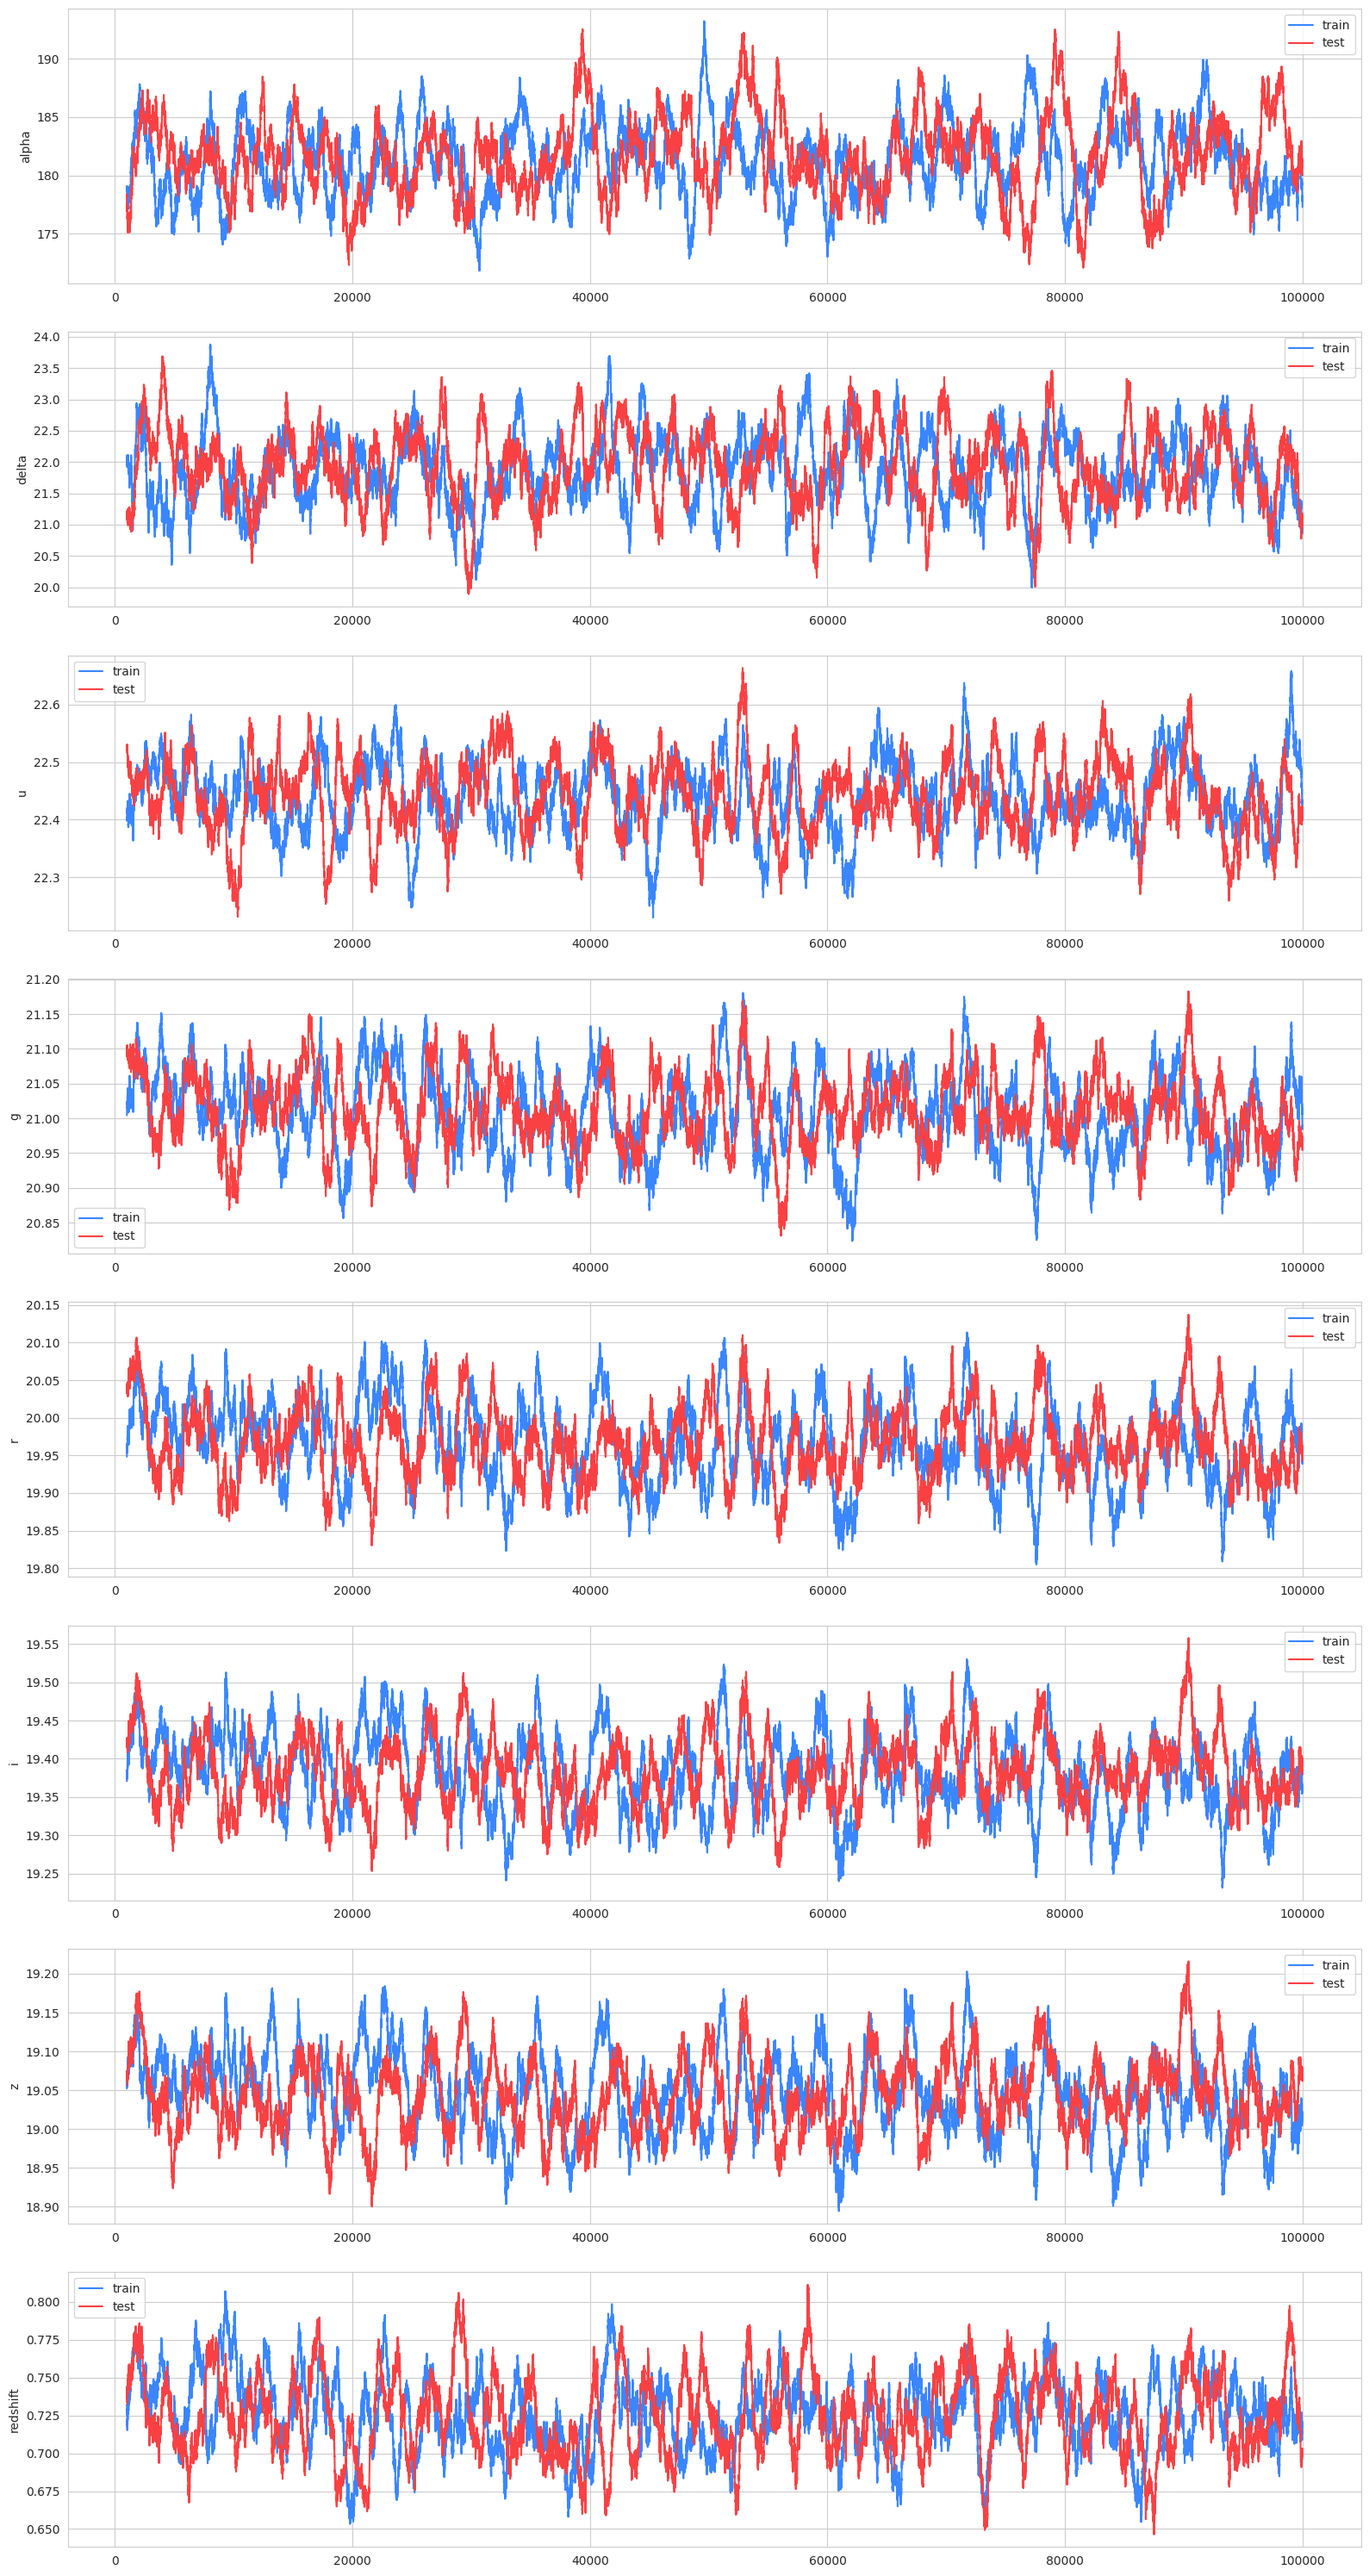

In [30]:
## -- DRIFT CHECK --
plt.figure(figsize=(16, 30))
_roll = 1000

for i, col in enumerate(NUMS):
    plt.subplot(len(NUMS), 1, i+1)
    sns.lineplot(train[col].iloc[:len(orig)].rolling(_roll).mean(), label='train')
    sns.lineplot(test[col].iloc[:len(orig)].rolling(_roll).mean(), label='test')
    # sns.lineplot(orig[col].rolling(_roll).mean(), label='orig')

plt.legend()
plt.tight_layout(h_pad=2)
plt.show()

In [31]:
# %%time

# ## -- FEATURE MUTUAL INFO --
# mutual_info = mutual_info_regression(train[BASE], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#     dict(zip(test.columns.tolist(), list(mutual_info))),
#     orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# plt.figure(figsize=(18, 10))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title('-- Univariate Analysis: Top predictors --')
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) test

In [32]:
from scipy.stats import ks_2samp

def ks_driftcheck(df_1, df_2, df2_mame: str, features):
    df_train = df_1.copy()
    df_test  = df_2.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.05

    print(f"{'feature':<20}\t{'ks-stat':<8}\t{'drift'}")
    print(f"{'-'*20:<20}\t{'-------':<8}\t{'-------'}")
    RED = '\033[33m'
    for c in features:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 4)
        if ks_stat >= threshold:
            print(f"{CFG['YELLOW']}{c:<20}\t{ks_stat:<8}\t⚠️ Drift{CFG['RESET']}")
        else:
            print(f"{c:<20}\t{ks_stat:<8}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    print()
    plt.barh(cols, ks_stats_all, color=['r' if c >= threshold else 'gray'for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle='--', label=f'Drift threshold: {threshold}')
    plt.title(f"(K-S) drift test: TRAIN vs {df2_mame}", fontweight='semibold')
    plt.legend()
    plt.show()

    gc.collect()


feature             	ks-stat 	drift
--------------------	------- 	-------
alpha               	0.0021  	✅ Safe!
delta               	0.0014  	✅ Safe!
u                   	0.0009  	✅ Safe!
g                   	0.0018  	✅ Safe!
r                   	0.0017  	✅ Safe!
i                   	0.0024  	✅ Safe!
z                   	0.0028  	✅ Safe!
redshift            	0.0023  	✅ Safe!
spectral_type       	0.0015  	✅ Safe!
galaxy_population   	0.0015  	✅ Safe!



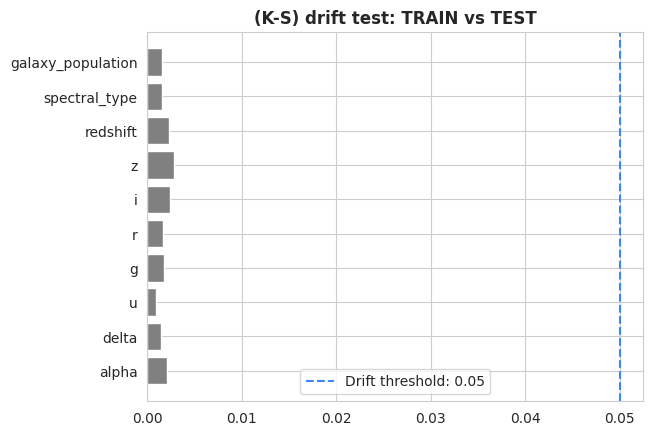

In [33]:
## -- Drift test for TRAIN & TEST --
ks_driftcheck(train, test, 'TEST', BASE)

In [34]:
# ## -- Drift test for TRAIN & ORIGINAL --
# ks_driftcheck(train, orig, 'ORIGINAL', BASE+[TARGET])

In [35]:
# try:
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset 
# except:
#     !pip install -qq -U evidently
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# def evid_driftcheck(df_1, df_2, features, nums, cats):
    
#     schema = DataDefinition(numerical_columns=nums, categorical_columns=cats)

#     train_df = Dataset.from_pandas(df_1[features], data_definition=schema)
#     test_df = Dataset.from_pandas(df_2[features], data_definition=schema)
    
#     report = Report([DataDriftPreset()])
#     my_eval = report.run(train_df, test_df)
#     display(my_eval)

In [36]:
# ## -- Drift test for TRAIN & TEST --
# evid_driftcheck(train, test, BASE, NUMS, CATS)

In [37]:
# ## -- Drift test for TRAIN & ORIGINAL --
# evid_driftcheck(train, orig, train.columns, NUMS, CATS+[TARGET])

In [38]:
# skew_col = orig.groupby('ST depression')[TARGET].skew().reset_index(name='skew_col').astype('float32')
# skew_col

# FEATURE ENGINEERING

In [39]:
# def compute_magic_score(df):
#     """Compute the magic formula score from Chris Deotte's discovery."""
#     high_score = (
#         (df["Soil_Moisture"] < 25).astype(int) * 2
#         + (df["Rainfall_mm"] < 300).astype(int) * 2
#         + (df["Temperature_C"] > 30).astype(int)
#         + (df["Wind_Speed_kmh"] > 10).astype(int)
#     )
#     low_score = (
#         (df["Crop_Growth_Stage"] == "Harvest").astype(int) * 2
#         + (df["Crop_Growth_Stage"] == "Sowing").astype(int) * 2
#         + (df["Mulching_Used"] == "Yes").astype(int)
#     )
#     return high_score - low_score

# train["magic_score"] = compute_magic_score(train)
# test["magic_score"]  = compute_magic_score(test)
# orig["magic_score"]  = compute_magic_score(orig)

# train.head()

In [40]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Category Mean ENCODERS =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [41]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"
            
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) 
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) 
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [42]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], ## --- (mean, count, std, nunique, median, max, min)
#     # fill_nan=True,
# )

# print(F"Total original featuresD: {len(orig_cols)}")

In [43]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c]]) # , orig[c]
    combine  = combine.factorize()[0]
    combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    # orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')
train.dtypes

Label encoding complete!


alpha                 float64
delta                 float64
u                     float64
g                     float64
r                     float64
i                     float64
z                     float64
redshift              float64
spectral_type        category
galaxy_population    category
class                   int64
dtype: object

In [44]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('📥 Total Features:', len(FEATURES))

train.head(3)

📥 Total Features: 10


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1


In [45]:
def target_encoder(X_tr, X_va, X_ts, y_tr, cols):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', cv=5, random_state=CFG['SEED'])

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in cols]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    return X_tr_1, X_va_1, X_ts_1

# ML TRAINING

In [46]:
## -- Define Models --
num_classes = train[TARGET].nunique()

tree_models = {
    'xgb_': xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        # learning_rate=0.05,
        eval_metric='mlogloss',
        enable_categorical=True,
        verbosity=0,
        random_state=CFG['SEED'],
        n_jobs=os.cpu_count(),
        device='cuda' if torch.cuda.is_available() else 'cpu',
    ),
    'lgb_': lgb.LGBMClassifier(
        objective='multiclass',
        metric='multiclass',
        num_classes=num_classes,
        # learning_rate=0.05,
        # cat_features=CATS,
        verbose=-1,
        random_state=CFG['SEED'],
        nthreads=os.cpu_count(),
        device='gpu' if torch.cuda.is_available() else 'cpu',
    ),
    'cat_': cgb.CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='MultiClass',
        classes_count=num_classes,
        cat_features=CATS,
        allow_writing_files=False,
        verbose=False,
        random_state=CFG['SEED'],
        thread_count=os.cpu_count(),
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
    ),
    'rfc_': RandomForestClassifier(
        # n_estimators=20,
        n_jobs=os.cpu_count(),
        random_state=CFG['SEED'],
    ),
    'hist_': HistGradientBoostingClassifier(tol=1e-4, random_state=CFG['SEED']),
}

print(f"Tree models to train: {len(tree_models)} -> ", end="")
print(list(tree_models.keys()))

Tree models to train: 5 -> ['xgb_', 'lgb_', 'cat_', 'rfc_', 'hist_']


Training models:   0%|          | 0/5 [00:00<?, ?it/s]


█████ [1] XGB_ 
***** Fold 1/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96333
Training calib model .... Complete! Score: 0.96307

***** Fold 2/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96356
Training calib model .... Complete! Score: 0.96303

***** Fold 3/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96259
Training calib model .... Complete! Score: 0.96291

***** Fold 4/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96191
Training calib model .... Complete! Score: 0.96163

***** Fold 5/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96406
Training calib model .... Complete! Score: 0.96404

***** Fold 6/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96239
Training calib model .... Complete! Score: 0.96247

***** Fold 7/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96210
Training cali

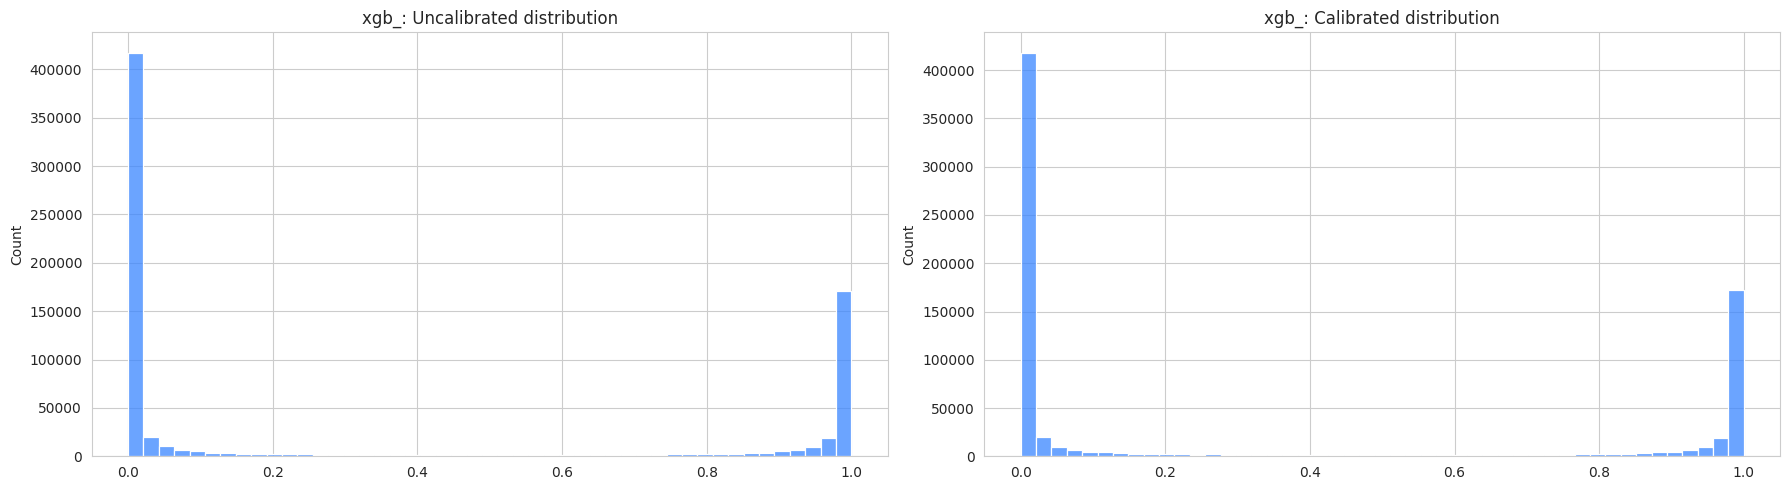


█████ [2] LGB_ 
***** Fold 1/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96056
Training calib model .... Complete! Score: 0.96042

***** Fold 2/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96142
Training calib model .... Complete! Score: 0.96087

***** Fold 3/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96079
Training calib model .... Complete! Score: 0.96067

***** Fold 4/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.95981
Training calib model .... Complete! Score: 0.96001

***** Fold 5/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96017
Training calib model .... Complete! Score: 0.96003

***** Fold 6/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96073
Training calib model .... Complete! Score: 0.96084

***** Fold 7/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96027
Training cali

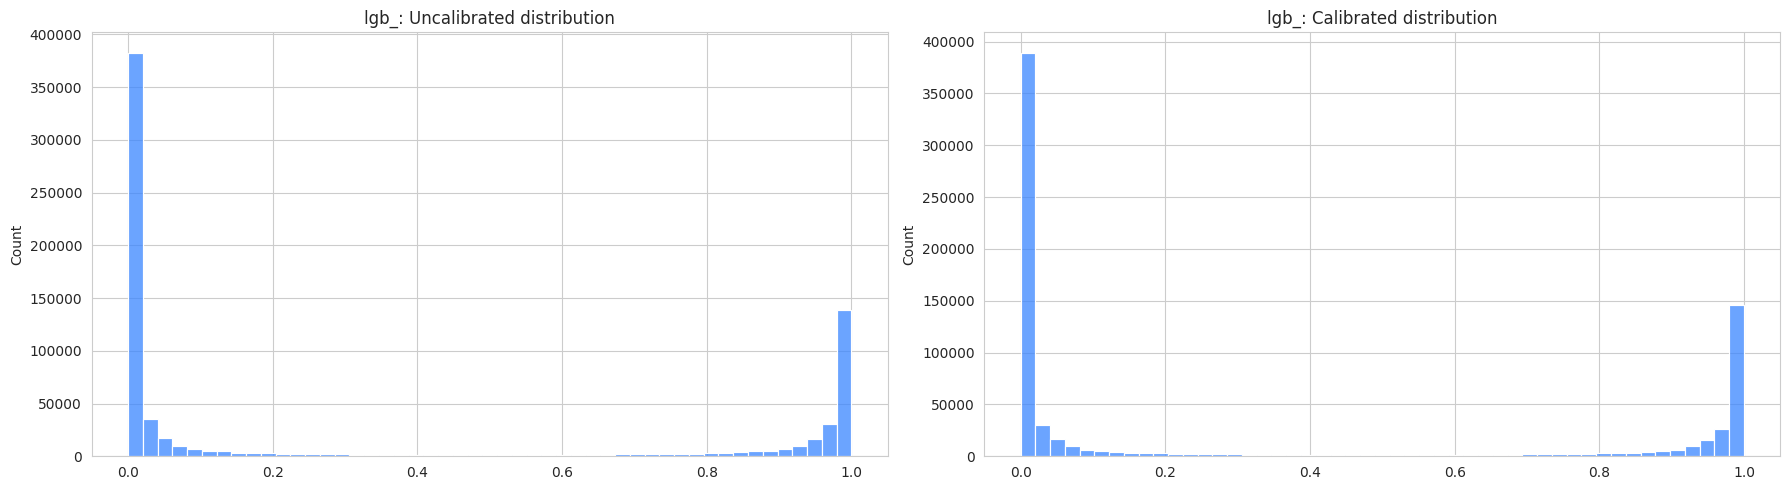


█████ [3] CAT_ 
***** Fold 1/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96164
Training calib model .... Complete! Score: 0.96178

***** Fold 2/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96227
Training calib model .... Complete! Score: 0.96227

***** Fold 3/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.96150
Training calib model .... Complete! Score: 0.96125

***** Fold 4/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96075
Training calib model .... Complete! Score: 0.96066

***** Fold 5/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96151
Training calib model .... Complete! Score: 0.96170

***** Fold 6/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96125
Training calib model .... Complete! Score: 0.96143

***** Fold 7/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.96101
Training cali

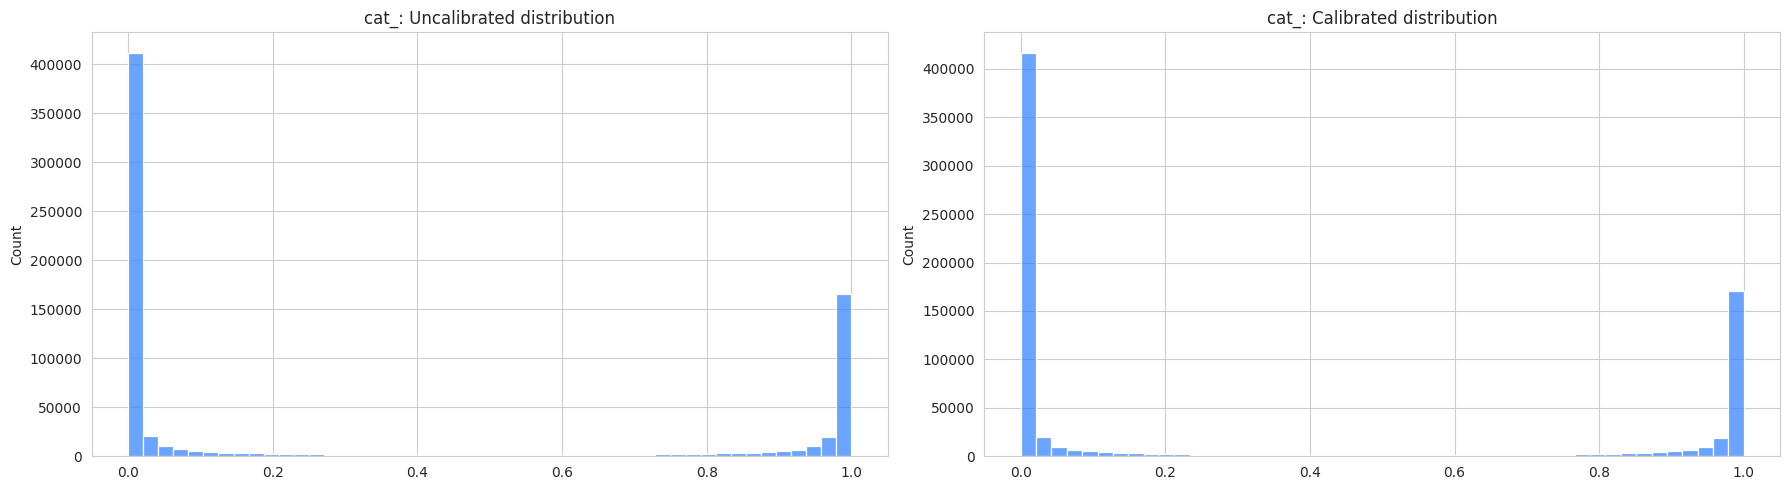


█████ [4] RFC_ 
***** Fold 1/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.94153
Training calib model .... Complete! Score: 0.95782

***** Fold 2/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.94239
Training calib model .... Complete! Score: 0.95839

***** Fold 3/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.94204
Training calib model .... Complete! Score: 0.95855

***** Fold 4/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.94043
Training calib model .... Complete! Score: 0.95616

***** Fold 5/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.94124
Training calib model .... Complete! Score: 0.95713

***** Fold 6/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.94159
Training calib model .... Complete! Score: 0.95801

***** Fold 7/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.94104
Training cali

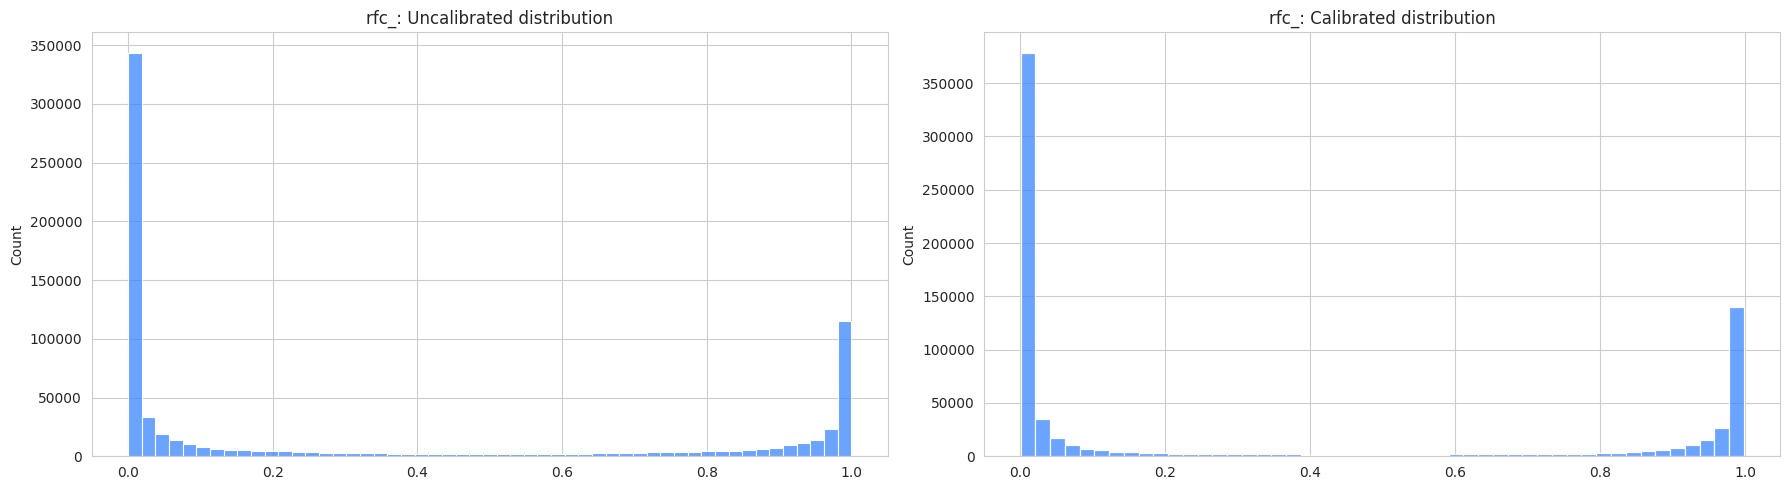


█████ [5] HIST_ 
***** Fold 1/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.95957
Training calib model .... Complete! Score: 0.96043

***** Fold 2/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.95914
Training calib model .... Complete! Score: 0.95951

***** Fold 3/8 | shape: (353624, 10) *****
Training base model ..... Complete! Score: 0.95960
Training calib model .... Complete! Score: 0.96002

***** Fold 4/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.95797
Training calib model .... Complete! Score: 0.95855

***** Fold 5/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.95885
Training calib model .... Complete! Score: 0.95907

***** Fold 6/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.95922
Training calib model .... Complete! Score: 0.95945

***** Fold 7/8 | shape: (353625, 10) *****
Training base model ..... Complete! Score: 0.95881
Training cal

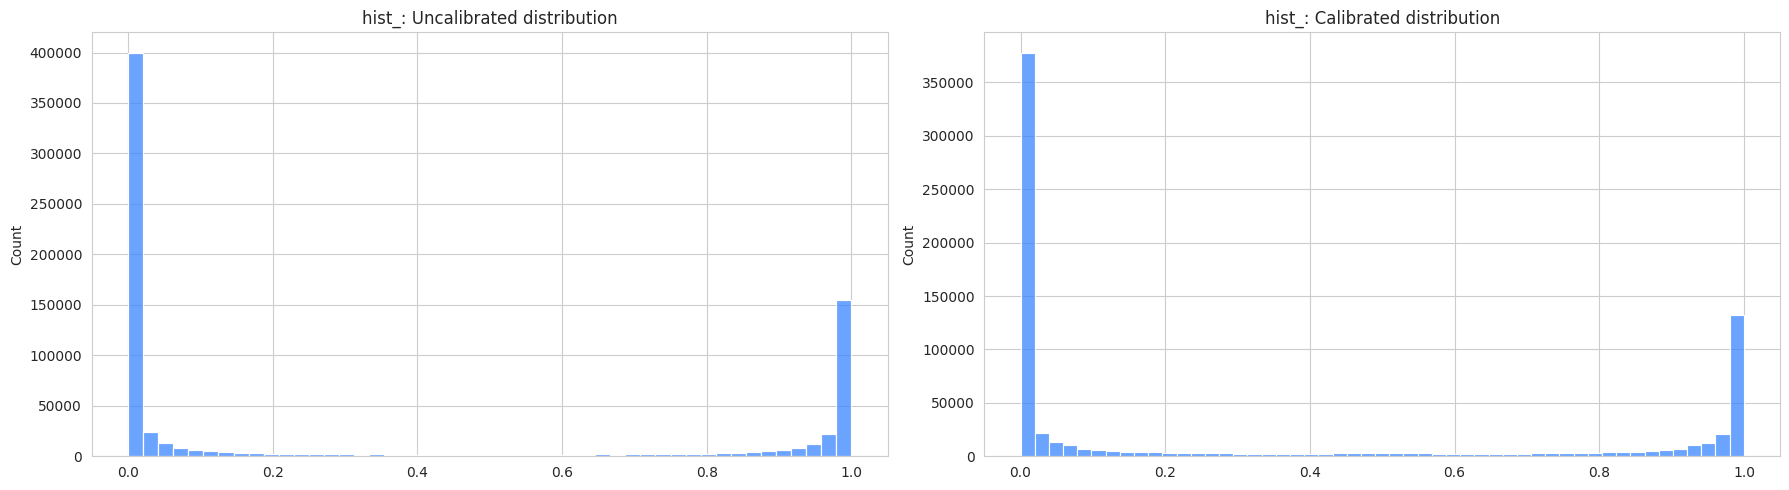

In [47]:
## -- Initiate Training -- 
base_classifiers = {}
model_scores     = {}
oof_final        = []
test_final       = []

calib_classifiers  = {}
calib_model_scores = {}
calib_oof_final    = []
calib_test_final   = []

X = train[FEATURES]
y = train[TARGET]

CFG['FOLDS'] = 8
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

_all_ = len(tree_models)
_desc = 'Training models'

for i, (name, base_model) in tqdm(enumerate(tree_models.items()), total=_all_, desc=_desc):
    print(f"\n{'█'*5} [{i+1}] {(name.upper())} ")
    tik = time()

    oof_preds  = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(test), num_classes))
    oof_scores = []

    calib_oof_preds  = np.zeros((len(X), num_classes))
    calib_test_preds = np.zeros((len(test), num_classes))
    calib_oof_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test[FEATURES].copy()

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        ## -- Factorize and convert categorical columns --
        if 'cat' in name:
            combined = pd.concat([X_train, X_valid, X_test])
            for c in CATS:
                combined[c] = combined[c].astype(str)
            X_train = combined[:len(X_train)]
            X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
            X_test  = combined[len(X_train)+len(X_valid):]

        ## -- Target Encoding -- 
        # X_train, X_valid, X_test = target_encoder(X_train, X_valid, X_test, y_train, NUMS)

        ## -- 2. Internal Split for Calibration --
        X_tr_base, X_tr_cal, y_tr_base, y_tr_cal = train_test_split(
        X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED'])

        ## -- Define sample weights --
        cls_ = np.unique(y)
        w_ = compute_class_weight('balanced', classes=cls_, y=y)
        sample_w_ = np.array([dict(zip(cls_, w_))[label] for label in y_tr_base])

        print(f"***** Fold {fold}/{kf.n_splits} | ", end='')
        print(f"shape: {X_tr_base.shape} *****")

        print(f'Training base model ..... ', end='')
        base_model.fit(X_tr_base, y_tr_base, sample_weight=sample_w_)
        oof_preds[val_idx] = base_model.predict_proba(X_valid)
        fold_score = balanced_accuracy_score(y_valid, np.argmax(oof_preds[val_idx], axis=1))
        oof_scores.append(fold_score)
        print(f'Complete! {CFG['YELLOW']}Score: {fold_score:.5f}{CFG['RESET']}')
        test_preds += base_model.predict_proba(X_test)

        ## -- Define sample weights --
        w_2 = compute_class_weight('balanced', classes=cls_, y=y_tr_base)
        sample_w_2 = np.array([dict(zip(cls_, w_2))[label] for label in y_tr_cal])

        ## -- Calibrator for 'true' probabilities --
        print(f'Training calib model .... ', end='')
        calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), method='isotonic', n_jobs=-1)
        calib_model.fit(X_tr_cal, y_tr_cal, sample_weight=sample_w_2)
        calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
        calib_fold_score = balanced_accuracy_score(y_valid, np.argmax(calib_oof_preds[val_idx], axis=1))
        calib_oof_scores.append(calib_fold_score)
        print(f'Complete! {CFG['YELLOW']}Score: {calib_fold_score:.5f}{CFG['RESET']}\n')
        calib_test_preds += calib_model.predict_proba(X_test)

    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    ## -- After all folds --
    overall_score = np.round(balanced_accuracy_score(y, np.argmax(oof_preds, axis=1)), 5)
    calib_overall_score = np.round(balanced_accuracy_score(y, np.argmax(calib_oof_preds, axis=1)), 5)
    
    print(f"{'='*40}")
    print(f"OOF  Base: {overall_score} | Calib: {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(oof_scores):.5f} ± {np.std(oof_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_oof_scores):.5f} ± {np.std(calib_oof_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{CFG['GREEN']}Improved : {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
    print(f"{'='*40}")

    tok = time()
    tiktok = tok-tik
    print(f"Time: {tiktok:.2f} secs")

    _, axs = plt.subplots(1, 2, figsize=(18, 5)) #, width_ratios=[0.6,0.4]

    sns.histplot(test_preds.ravel(), ax=axs[0])
    axs[0].set_title(f"{name}: Uncalibrated distribution")

    sns.histplot(calib_test_preds.ravel(), ax=axs[1])
    axs[1].set_title(f"{name}: Calibrated distribution")

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    COL_NAME_1 = {v: name+k for k, v in mapping.items()}
    base_classifiers[n] = base_model
    model_scores[n] = overall_score.item()
    oof_final.append(pd.DataFrame(oof_preds).rename(columns=COL_NAME_1))
    test_final.append(pd.DataFrame(test_preds).rename(columns=COL_NAME_1))

    c_n = name + str(calib_overall_score).split('.')[1]
    COL_NAME_2 = {v: 'calib_'+name+k for k, v in mapping.items()}
    calib_oof_final.append(pd.DataFrame(calib_oof_preds).rename(columns=COL_NAME_2))
    calib_test_final.append(pd.DataFrame(calib_test_preds).rename(columns=COL_NAME_2))
    calib_classifiers[c_n] = calib_model
    calib_model_scores[c_n] = calib_overall_score.item()

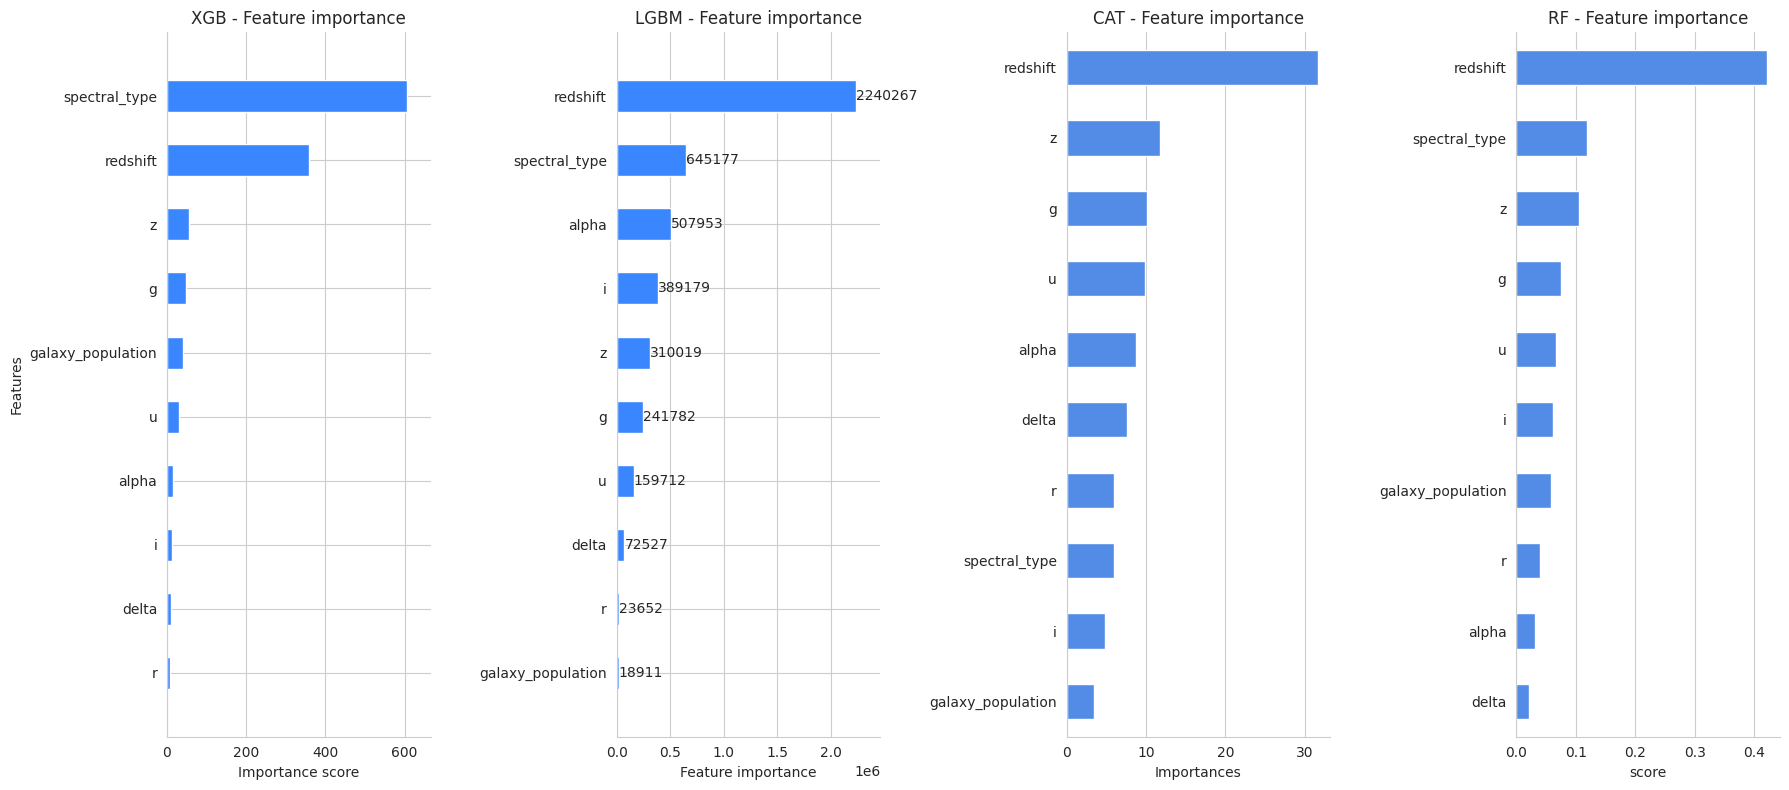

In [48]:
## -- Plot Feature Importances -- 
MAX = 15
fig, axs = plt.subplots(1, 4, figsize=(18, 8))

for k, v in calib_classifiers.items():
    ## -- XGBoost --
    if 'xgb' in k:
        xgb.plot_importance(
            v.calibrated_classifiers_[0].estimator.estimator,
            max_num_features=MAX,
            importance_type='gain',
            title='XGB - Feature importance',
            height=0.5, show_values=False, ax=axs[0], # grid=False,
        )

    ## -- LightGBM -- 
    elif 'lgb' in k:
        lgb.plot_importance(
            v.calibrated_classifiers_[0].estimator.estimator,
            max_num_features=MAX,
            importance_type='gain',
            title='LGBM - Feature importance',
            height=0.5, precision=0, ax=axs[1], # grid=False,
        )
        axs[1].set_ylabel('')
    
    ## -- CatBoost -- 
    elif 'cat' in k:
        cat_imp_df = v.calibrated_classifiers_[0].estimator.estimator\
                      .get_feature_importance(prettified=True).iloc[:MAX]
        sns.barplot(data=cat_imp_df, x='Importances', y='Feature Id', width=0.5, ax=axs[2])
        axs[2].set_title('CAT - Feature importance')
        axs[2].set_ylabel('')
    
    ## -- RandomForest -- 
    elif 'rfc' in k:
        rf_dicts = dict(zip(X_train.columns, v.calibrated_classifiers_[0].estimator.estimator.feature_importances_))
        rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient='index', columns=['score'])\
                                .sort_values('score', ascending=False).iloc[:MAX]
        sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[3])
        axs[3].set_title('RF - Feature importance')
        axs[3].set_ylabel('')
    
    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()


In [49]:
try:
    import shap
except:
    %pip install -q -U shap
    import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


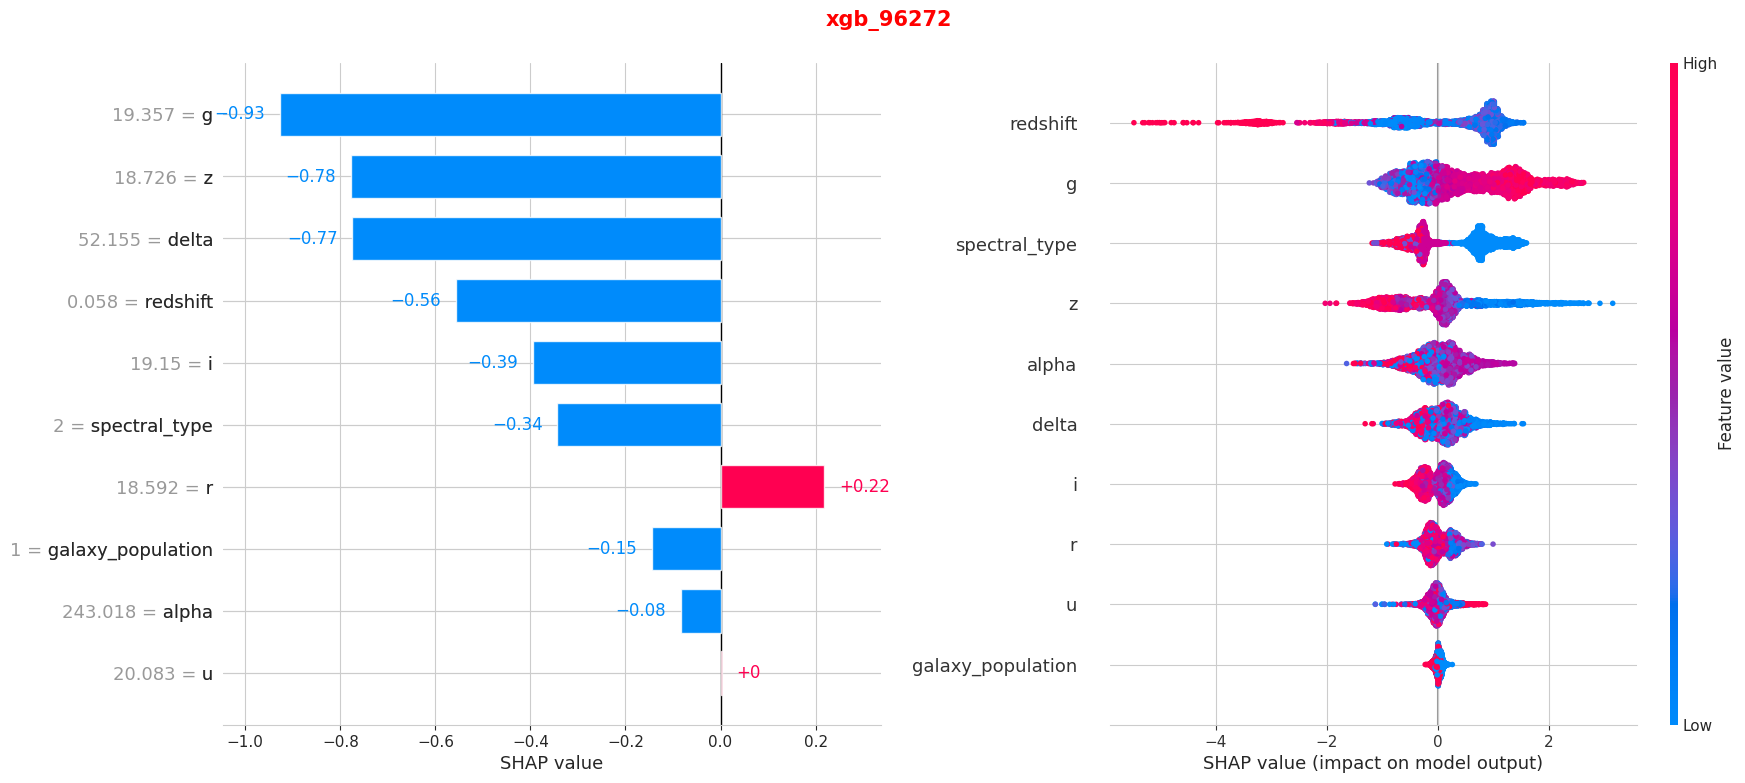

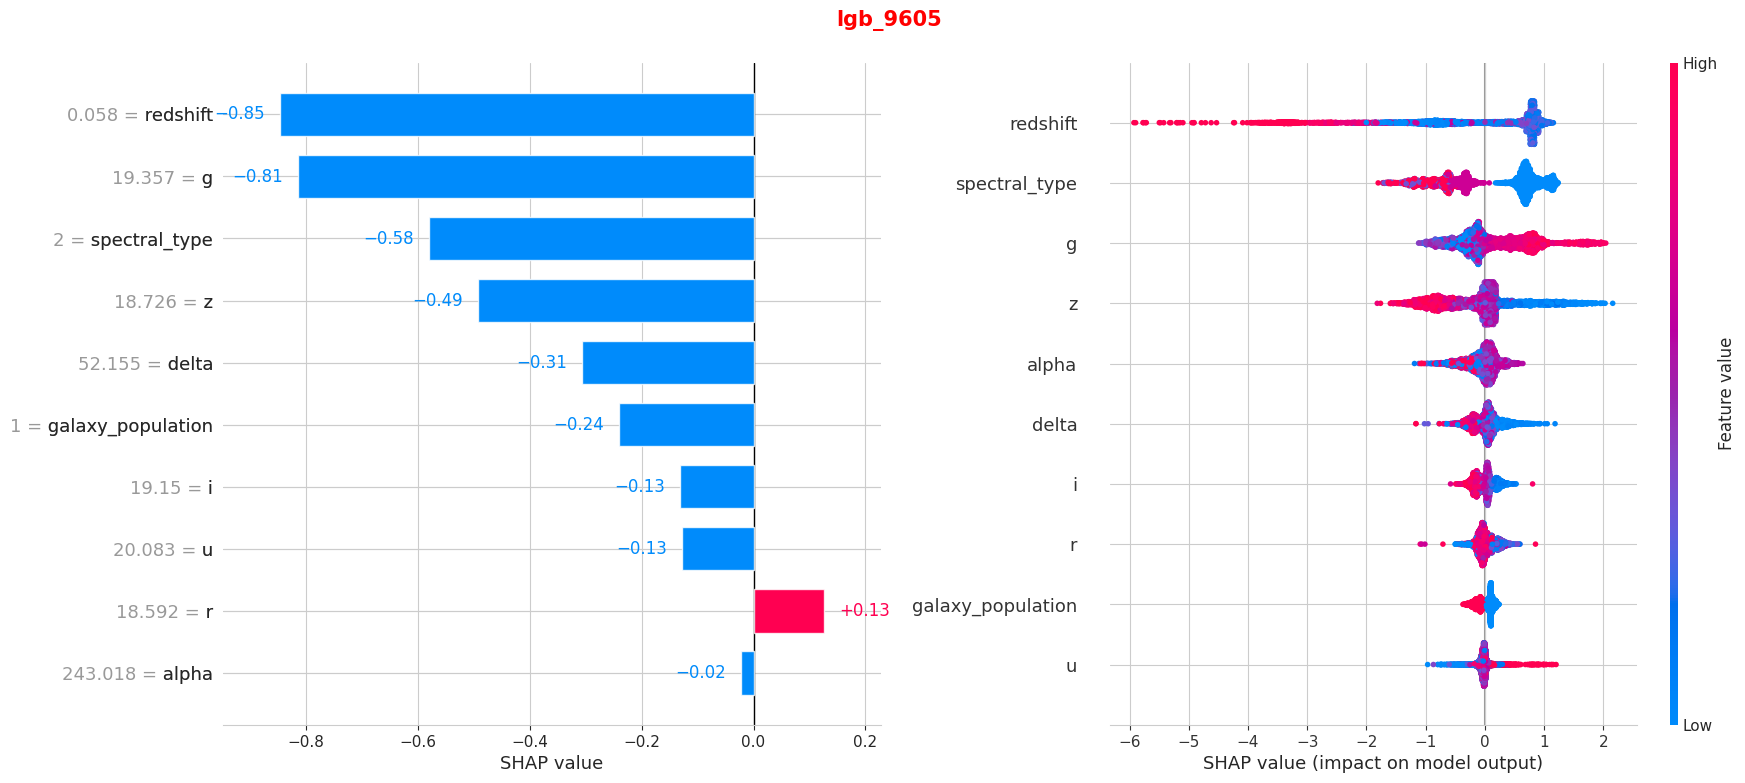

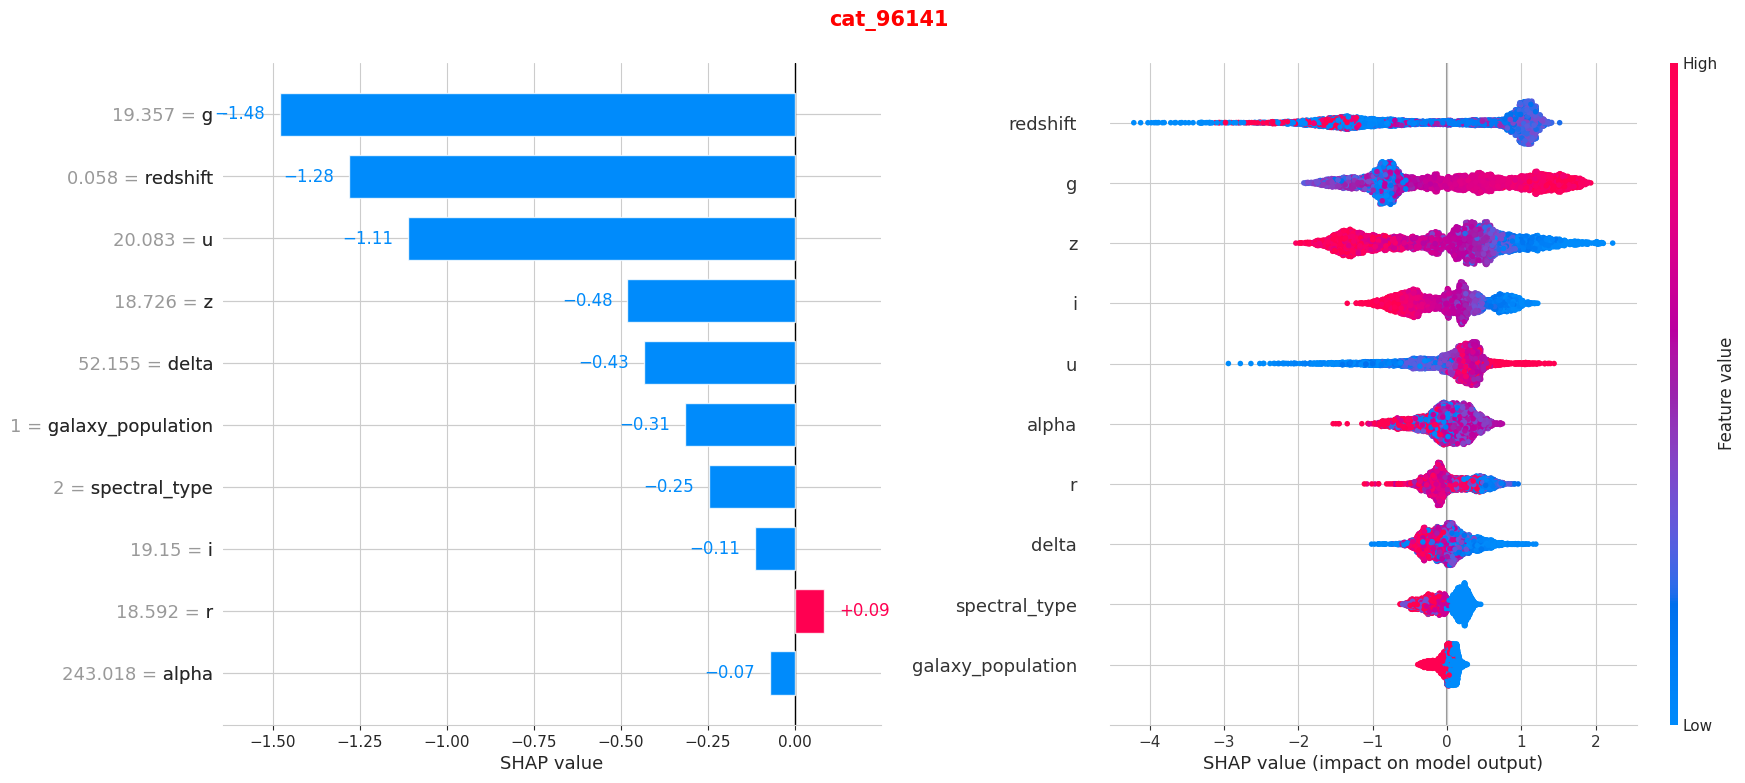

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:
## -- Plot SHAP values --
MAX = 15
class_id    = 0 #-> Select which class
instance_id = 0 #-> Select an instance

for i, (name, model) in enumerate(calib_classifiers.items()):
    if 'xgb' in name or 'lgb' in name or 'cat' in name:
        explainer = shap.TreeExplainer(model.calibrated_classifiers_[0].estimator.estimator)
        explanation = explainer(X_tr_cal.iloc[:5000])
        explanation.output_names = [*mapping.keys()]

        ## -- Bar plot --
        plt.subplot(121)
        shap.plots.bar(explanation[instance_id, :, class_id], max_display=MAX, show=False)
        # plt.title('Bar - Overall impact on model predictions', fontweight='semibold')

        ## -- Beeswarm plot --
        plt.subplot(122)
        shap.plots.beeswarm(
            explanation[:, :, class_id], max_display=MAX, #order=explanation.abs.max(0),
            plot_size=(18, 8), color_bar=True, show=False,
        )

        # plt.title('Beeswarm - Most impactful features', fontweight='semibold')
        plt.suptitle(f"{name}", fontweight='bold', fontsize=15, color='r')

    plt.tight_layout(pad=1.5) 
    plt.show() 
    print()


In [51]:
## -- Define Models --
num_classes = train[TARGET].nunique()

linear_models = {
    # 'log_': LogisticRegressionCV(
    #     max_iter=5000,
    #     scoring='neg_log_loss',
    #     # C=1e-3,
    #     tol=1e-4,
    #     # class_weight='balanced',
    #     n_jobs=os.cpu_count(),
    #     random_state=CFG['SEED'],
    # ),
    'knnU_': KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        # leaf_sizee=30,
        n_jobs=os.cpu_count(),
    ),
    'knnD_': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        # leaf_sizee=30,
        n_jobs=os.cpu_count(),
    ),
    'mlp_': MLPClassifier(max_iter=100, tol=1e-4, random_state=CFG['SEED']),
}

print(f"Linear models to train: {len(linear_models)} -> ", end="")
print(list(linear_models.keys()))

Linear models to train: 3 -> ['knnU_', 'knnD_', 'mlp_']


Training models:   0%|          | 0/3 [00:00<?, ?it/s]


█████ [1] KNNU_ 
***** Fold 1/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.91832
Training calib model.... Complete! Score: 0.93397

***** Fold 2/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.92108
Training calib model.... Complete! Score: 0.93796

***** Fold 3/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.91950
Training calib model.... Complete! Score: 0.93503

***** Fold 4/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.91817
Training calib model.... Complete! Score: 0.93395

***** Fold 5/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.91888
Training calib model.... Complete! Score: 0.93448

***** Fold 6/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.91969
Training calib model.... Complete! Score: 0.93474

***** Fold 7/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.92125
Training calib model.... 

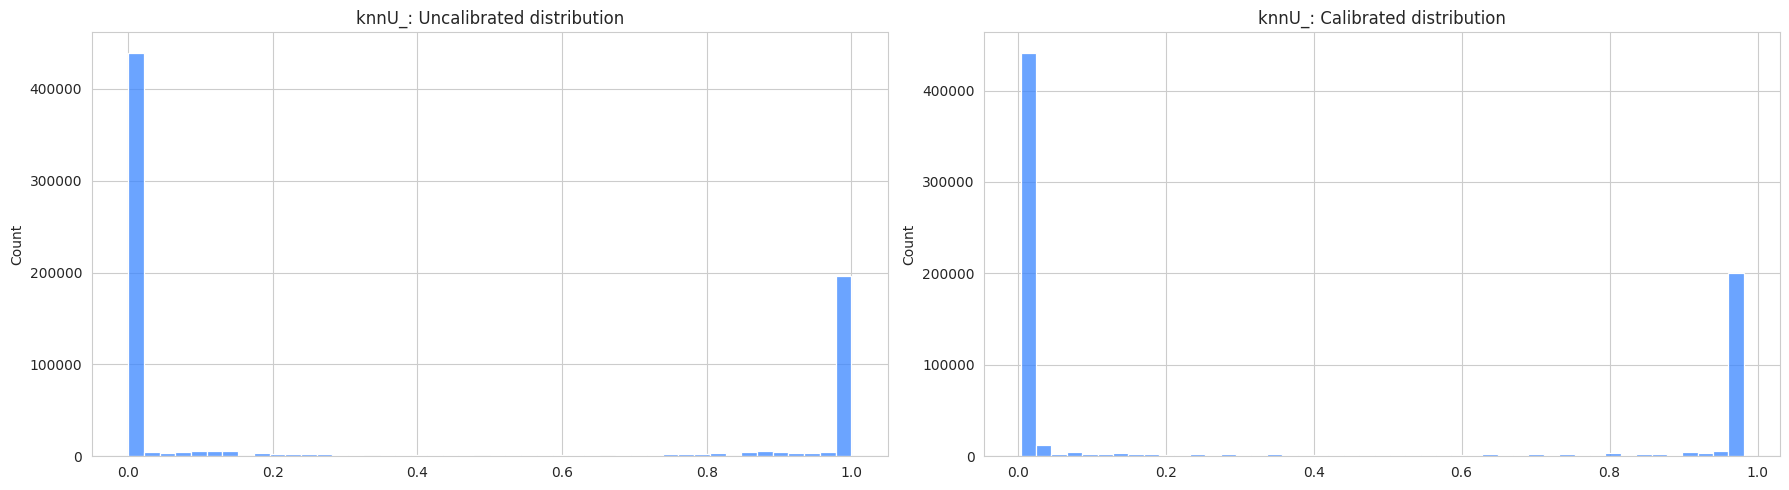


█████ [2] KNND_ 
***** Fold 1/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.91929
Training calib model.... Complete! Score: 0.93481

***** Fold 2/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.92159
Training calib model.... Complete! Score: 0.93820

***** Fold 3/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.92080
Training calib model.... Complete! Score: 0.93692

***** Fold 4/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.91918
Training calib model.... Complete! Score: 0.93531

***** Fold 5/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.91988
Training calib model.... Complete! Score: 0.93632

***** Fold 6/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.92041
Training calib model.... Complete! Score: 0.93640

***** Fold 7/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.92235
Training calib model.... 

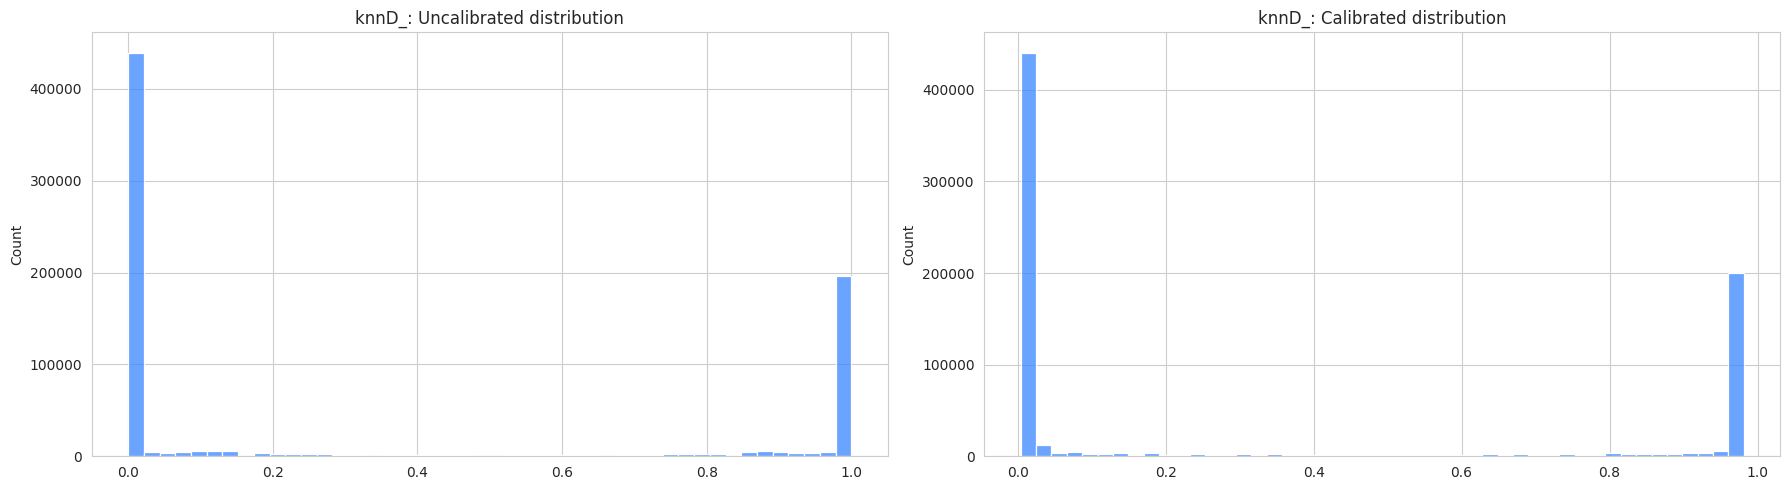


█████ [3] MLP_ 
***** Fold 1/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.93801
Training calib model.... Complete! Score: 0.95237

***** Fold 2/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.93587
Training calib model.... Complete! Score: 0.95413

***** Fold 3/8 | shape: (353624, 14) *****
Training base model..... Complete! Score: 0.93332
Training calib model.... Complete! Score: 0.95321

***** Fold 4/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.93072
Training calib model.... Complete! Score: 0.95163

***** Fold 5/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.93817
Training calib model.... Complete! Score: 0.95241

***** Fold 6/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.94130
Training calib model.... Complete! Score: 0.95125

***** Fold 7/8 | shape: (353625, 14) *****
Training base model..... Complete! Score: 0.93518
Training calib model.... C

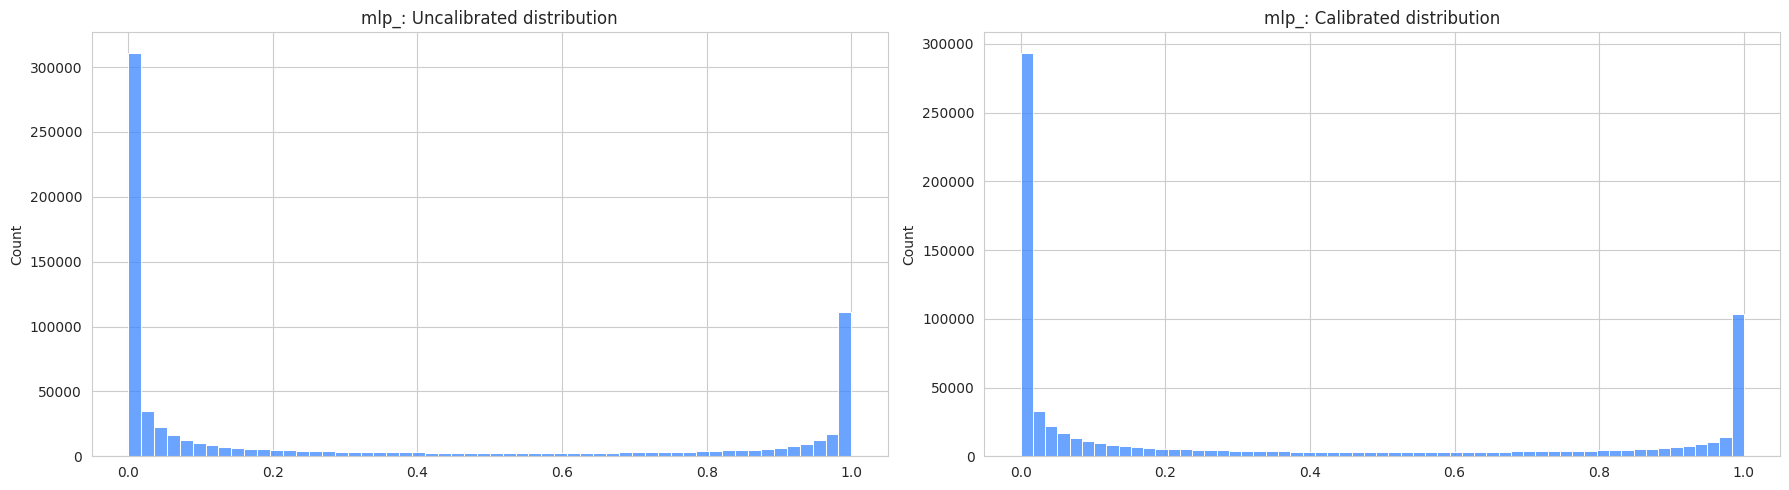

In [52]:
## -- Initiate Training -- 
# base_classifiers = {}
# model_scores     = {}
# oof_final        = pd.DataFrame()
# test_final       = pd.DataFrame()

# calib_classifiers  = {}
# calib_model_scores = {}
# calib_oof_final    = pd.DataFrame()
# calib_test_final   = pd.DataFrame()

X = train[FEATURES]
y = train[TARGET]

CFG['FOLDS'] = 8
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

_all_ = len(linear_models)
_desc = 'Training models'

for i, (name, base_model) in tqdm(enumerate(linear_models.items()), total=_all_, desc=_desc):
    print(f"\n{'█'*5} [{i+1}] {(name.upper())} ")
    tik = time()

    oof_preds  = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(test), num_classes))
    oof_scores = []

    calib_oof_preds  = np.zeros((len(X), num_classes))
    calib_test_preds = np.zeros((len(test), num_classes))
    calib_oof_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test[FEATURES].copy()

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- Factorize and convert categorical columns --
        # combine = pd.concat([X_train, X_val, X_test])
        # for c in CATS:
        #     combine[c] = combine[c].factorize()[0]
        #     combine[c] = combine[c].astype('category')
        # X_train = combine.iloc[:len(X_train)]
        # X_val   = combine.iloc[len(X_train):len(X_train)+len(X_val)]
        # X_test  = combine.iloc[len(X_train)+len(X_val):]

        ## -- Target Encoding -- 
        # X_train, X_val, X_test = target_encoder(X_train, X_val, X_test, y_train, NUMS)

        combined = pd.concat([X_train, X_valid, X_test])
        combined_d = pd.get_dummies(combined, columns=CATS, dtype=np.int8)
        X_train = combined_d[:len(X_train)]
        X_valid = combined_d[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined_d[len(X_train)+len(X_valid):]

        for col in NUMS:
            scaler = StandardScaler()
            X_train.loc[:, col] = scaler.fit_transform(X_train[[col]])
            X_valid.loc[:, col] = scaler.transform(X_valid[[col]])
            X_test.loc[:, col]  = scaler.transform(X_test[[col]])

        ## -- 2. Internal Split for Calibration --
        X_tr_base, X_tr_cal, y_tr_base, y_tr_cal = train_test_split(
        X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED'])

        ## -- Define sample weights --
        cls_ = np.unique(y)
        w_ = compute_class_weight('balanced', classes=cls_, y=y)
        sample_w_ = np.array([dict(zip(cls_, w_))[label] for label in y_tr_base])

        print(f"***** Fold {fold}/{kf.n_splits} | ", end='')
        print(f"shape: {X_tr_base.shape} *****")
        
        print(f'Training base model..... ', end='')

        if 'knn' in name or 'mlp' in name:
            base_model.fit(X_tr_base, y_tr_base)
        else:
            base_model.fit(X_tr_base, y_tr_base, sample_weight=sample_w_)
            
        oof_preds[val_idx] = base_model.predict_proba(X_valid)
        fold_score = balanced_accuracy_score(y_valid, np.argmax(oof_preds[val_idx], axis=1))
        oof_scores.append(fold_score)
        print(f'Complete! {CFG['YELLOW']}Score: {fold_score:.5f}{CFG['RESET']}')
        test_preds += base_model.predict_proba(X_test)

        ## -- Define sample weights --
        w_2 = compute_class_weight('balanced', classes=cls_, y=y_tr_base)
        sample_w_2 = np.array([dict(zip(cls_, w_2))[label] for label in y_tr_cal])

        ## -- Calibrator for "true" probabilities --
        print(f'Training calib model.... ', end='')
        calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), method='isotonic', n_jobs=-1)
        calib_model.fit(X_tr_cal, y_tr_cal, sample_weight=sample_w_2) #
        calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
        calib_fold_score = balanced_accuracy_score(y_valid, np.argmax(calib_oof_preds[val_idx], axis=1))
        calib_oof_scores.append(calib_fold_score)
        print(f'Complete! {CFG['YELLOW']}Score: {calib_fold_score:.5f}{CFG['RESET']}\n')
        calib_test_preds += calib_model.predict_proba(X_test)

    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    ## -- After all folds --
    overall_score = np.round(balanced_accuracy_score(y, np.argmax(oof_preds, axis=1)), 5)
    calib_overall_score = np.round(balanced_accuracy_score(y, np.argmax(calib_oof_preds, axis=1)), 5)
    
    print(f"{'='*40}")
    print(f"OOF  Base: {overall_score} | Calib: {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(oof_scores):.5f} ± {np.std(oof_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_oof_scores):.5f} ± {np.std(calib_oof_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{CFG['GREEN']}Improved : {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
    print(f"{'='*40}")

    tok = time()
    tiktok = tok-tik
    print(f"Time: {tiktok:.2f} secs")

    _, axs = plt.subplots(1, 2, figsize=(18, 5)) #, width_ratios=[0.6,0.4]

    sns.histplot(test_preds.ravel(), ax=axs[0])
    axs[0].set_title(f"{name}: Uncalibrated distribution")

    sns.histplot(calib_test_preds.ravel(), ax=axs[1])
    axs[1].set_title(f"{name}: Calibrated distribution")
    
    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    COL_NAME_1 = {v: name+k for k, v in mapping.items()}
    oof_final.append(pd.DataFrame(oof_preds).rename(columns=COL_NAME_1))
    test_final.append(pd.DataFrame(test_preds).rename(columns=COL_NAME_1))
    base_classifiers[n] = base_model
    model_scores[n] = overall_score.item()

    c_n = name + str(calib_overall_score).split('.')[1]
    COL_NAME_2 = {v: 'calib_'+name+k for k, v in mapping.items()}
    calib_oof_final.append(pd.DataFrame(calib_oof_preds).rename(columns=COL_NAME_2))
    calib_test_final.append(pd.DataFrame(calib_test_preds).rename(columns=COL_NAME_2))
    calib_classifiers[c_n] = calib_model
    calib_model_scores[c_n] = calib_overall_score.item()

In [53]:
model_scores, calib_model_scores

({'xgb_96278': 0.96278,
  'lgb_96058': 0.96058,
  'cat_96144': 0.96144,
  'rfc_94153': 0.94153,
  'hist_95893': 0.95893,
  'knnU_91986': 0.91986,
  'knnD_92073': 0.92073,
  'mlp_93634': 0.93634},
 {'xgb_96272': 0.96272,
  'lgb_9605': 0.9605,
  'cat_96141': 0.96141,
  'rfc_95764': 0.95764,
  'hist_95931': 0.95931,
  'knnU_93494': 0.93494,
  'knnD_9363': 0.9363,
  'mlp_95254': 0.95254})

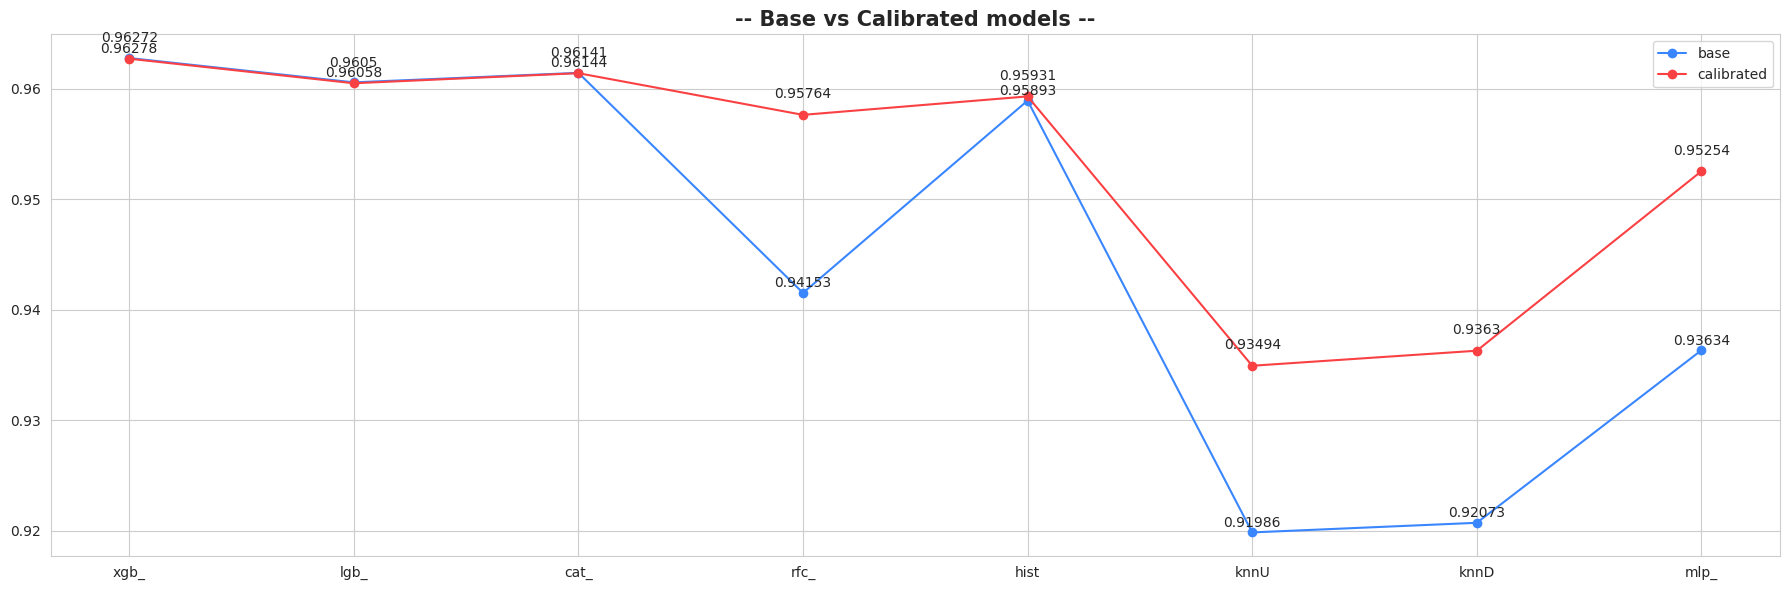

In [54]:
# __ = model_scores | calib_model_scores

ax = pd.Series(model_scores).plot.line(marker='o', label='base', figsize=(18, 6))
for i, v in enumerate(model_scores.values()):
    plt.text(i, v+5e-4, f'{v}', ha='center')

pd.Series(calib_model_scores).plot.line(marker='o', ax=ax, label='calibrated')
for i, v in enumerate(calib_model_scores.values()):
    plt.text(i, v+0.0015, f'{v}', ha='center')

plt.xticks(range(len(model_scores)), [c[:4] for c in model_scores.keys()])
plt.title('-- Base vs Calibrated models --', fontsize=15, fontweight='semibold')
# plt.ylim(.94, .97)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# !rm -r /kaggle/working

# ~ STACKING

In [56]:
from scipy.special import logit

def Stack_Trainer(oof_df, test_df, name='model_'):
    ## -- Define Training Parameters --
    stack_oof_preds  = np.zeros((len(oof_df), num_classes))
    stack_test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []
    
    for c in oof_df.columns:
        if 'stack' in c:
            oof_df.drop([c], axis=1, inplace=True)
            test_df.drop([c], axis=1, inplace=True)
        else:
            continue
    
    ## -- Split data --
    X = oof_df.copy()
    y = train[TARGET]

    ## -- Initiate Training --
    tik = time()
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"Fold {fold+1}/{kf.n_splits} • Models: {len(oof_final)} • ", end='')
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df.copy()
    
        cls_ = np.unique(y_train)
        w_   = compute_class_weight('balanced', classes=cls_, y=y_train)
        cw_  = dict(zip(cls_, w_))
        sw_  = np.array([cw_[label] for label in y_train])

        eps = 1e-10
        for col in X_train.columns:
            X_train.loc[:, col] = logit(np.clip(X_train[col].to_numpy(), eps, 1 - eps))
            X_valid.loc[:, col] = logit(np.clip(X_valid[col].to_numpy(), eps, 1 - eps))
            X_test.loc[:, col]  = logit(np.clip(X_test[col].to_numpy(), eps, 1 - eps))

        for col in X.columns:
            scaler = StandardScaler()
            X_train.loc[:, col] = scaler.fit_transform(X_train[[col]])
            X_valid.loc[:, col] = scaler.transform(X_valid[[col]])
            X_test.loc[:, col]  = scaler.transform(X_test[[col]])

        meta_model = LogisticRegressionCV(
            max_iter=1000,
            tol=1e-4,
            cv=5,
            scoring='neg_log_loss',
            # class_weight='balanced',
            n_jobs=os.cpu_count(),
            random_state=CFG['SEED']
        )
    
        meta_model.fit(X_train, y_train, sample_weight=sw_)
    
        stack_oof_preds[val_idx] = meta_model.predict_proba(X_valid)
        oof_score = np.round(balanced_accuracy_score(y_valid, np.argmax(stack_oof_preds[val_idx], axis=1)), 5)
        fold_scores.append(oof_score)
        print(f"Score: {oof_score}")
    
        stack_test_preds += meta_model.predict_proba(X_test)
    
    stack_test_preds /= kf.n_splits
    
    tok = time()
    tiktok = (tok-tik)
    
    ## -- After all folds --
    stack_score = np.round(balanced_accuracy_score(y, np.argmax(stack_oof_preds, axis=1)), 5)
    stack_name = name + str(stack_score).split('.')[1]
    
    COL_NAME = {v: stack_name+k for k, v in mapping.items()}
    meta_oof_df  = pd.DataFrame(stack_oof_preds).rename(columns=COL_NAME)
    meta_test_df = pd.DataFrame(stack_test_preds).rename(columns=COL_NAME)

    print(f"|{'-'*30}")
    print(f"| OOF Score: {stack_score}")
    print(f"| AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"|{'-'*30}")
    print(f"| Time: {tiktok:.2f} secs")

    return meta_oof_df, meta_test_df, {stack_name: stack_score.item()}, meta_model

In [57]:
## -- Base stacking --
base_stack_oof, base_stack_test, base_stack_score, base_stack_meta = Stack_Trainer(
    pd.concat(oof_final, axis=1),
    pd.concat(test_final, axis=1),
    'base_log_stack_',
)

base_scores = model_scores | base_stack_score
base_scores

bs = [str(c).strip('0.') for c in base_stack_score.values()][0]

sub = f"submit_base_logitStack_{bs}.csv"
submit[TARGET] = pd.Series(np.argmax(base_stack_test, axis=1)).map(r_mapping)
submit.to_csv(sub, index=False)
print('Submission file saved as:', sub)

submit.head(10)

Fold 1/8 • Models: 8 • Score: 0.9641
Fold 2/8 • Models: 8 • Score: 0.96436
Fold 3/8 • Models: 8 • Score: 0.96293
Fold 4/8 • Models: 8 • Score: 0.96309
Fold 5/8 • Models: 8 • Score: 0.96432
Fold 6/8 • Models: 8 • Score: 0.96331
Fold 7/8 • Models: 8 • Score: 0.96313
Fold 8/8 • Models: 8 • Score: 0.96369
|------------------------------
| OOF Score: 0.96361
| AVG Score: 0.96362 ± 0.00054
|------------------------------
| Time: 217.29 secs
Submission file saved as: submit_base_logitStack_96361.csv


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [58]:
## -- Calibrated stacking --
calib_stack_oof, calib_stack_test, calib_stack_score, calib_stack_meta = Stack_Trainer(
    pd.concat(calib_oof_final, axis=1),
    pd.concat(calib_test_final, axis=1),
    'calib_log_stack_',
)

calib_scores = calib_model_scores | calib_stack_score
calib_scores

cs = [str(c).strip('0.') for c in calib_stack_score.values()][0]

sub = f"submit_calib_logitStack_{cs}.csv"
submit[TARGET] = pd.Series(np.argmax(calib_stack_test, axis=1)).map(r_mapping)
submit.to_csv(sub, index=False)
print('Submission file saved as:', sub)

submit.head(10)

Fold 1/8 • Models: 8 • Score: 0.9636
Fold 2/8 • Models: 8 • Score: 0.96436
Fold 3/8 • Models: 8 • Score: 0.96308
Fold 4/8 • Models: 8 • Score: 0.96307
Fold 5/8 • Models: 8 • Score: 0.96437
Fold 6/8 • Models: 8 • Score: 0.96354
Fold 7/8 • Models: 8 • Score: 0.96325
Fold 8/8 • Models: 8 • Score: 0.96346
|------------------------------
| OOF Score: 0.96359
| AVG Score: 0.96359 ± 0.00048
|------------------------------
| Time: 279.78 secs
Submission file saved as: submit_calib_logitStack_96359.csv


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


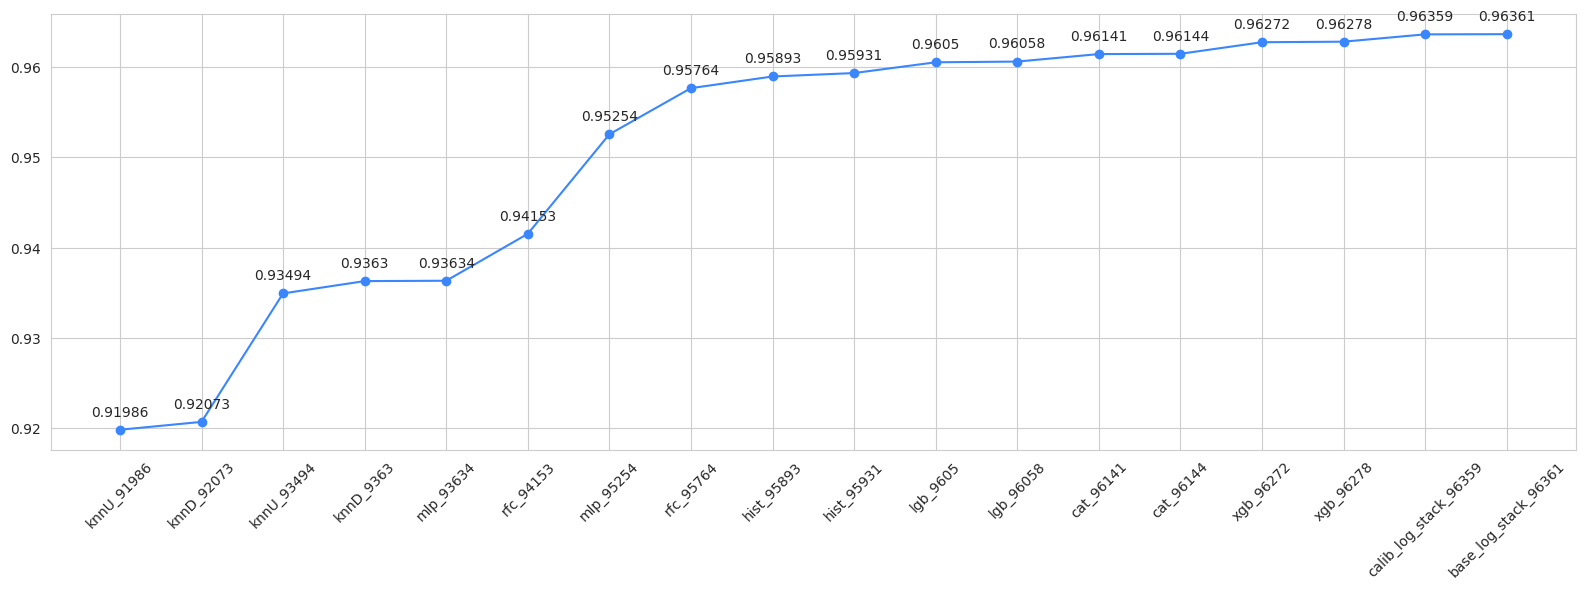

In [59]:
plt.figure(figsize=(16, 6))

all_scores = base_scores | calib_scores
all_score_df = pd.Series(all_scores).sort_values()
ax = all_score_df.plot.line(marker='o', rot=45)
ax.set_xticks(range(len(all_score_df)), [*all_score_df.index])

for i, v in enumerate(all_score_df.values):
    plt.text(i, v+0.0015, f'{v}', ha='center')

plt.tight_layout()
plt.show()

# ~ WEIGHTS OPTIMIZATION

In [60]:
def tune_weights_scipy(oof_proba, y_true):
    def objective(w):
        weights = np.array([1.0, w[0], w[1]])  # fix Low=1.0
        adjusted = oof_proba * weights
        preds = np.argmax(adjusted, axis=1)
        return -balanced_accuracy_score(y_true, preds) # negative because we minimize
    
    # try multiple starting points to avoid local minima
    best_result = None
    best_score = -1.0
    
    starts = [
        [1.0, 1.0],
        [0.8, 1.5],
        [1.2, 2.0],
        [0.7, 3.0],
        [1.0, 5.0],
        [0.9, 2.5],
    ]
    
    for x0 in starts:
        result = minimize(objective, x0, method='Nelder-Mead',
                          options={'maxiter': 2000, 'xatol': 1e-5, 'fatol': 1e-5, 'disp': True})
        if -result.fun > best_score:
            best_score = -result.fun
            best_result = result

    best_weights = np.array([1.0, best_result.x[0], best_result.x[1]])
    
    return best_weights, best_score


## OPTIMIZATION & SUBMISSION

In [61]:
mapping

{'GALAXY': 0, 'QSO': 1, 'STAR': 2}

Optimization terminated successfully.
         Current function value: -0.963680
         Iterations: 25
         Function evaluations: 62
Optimization terminated successfully.
         Current function value: -0.963619
         Iterations: 31
         Function evaluations: 80
Optimization terminated successfully.
         Current function value: -0.963715
         Iterations: 45
         Function evaluations: 96
Optimization terminated successfully.
         Current function value: -0.963664
         Iterations: 38
         Function evaluations: 88
Optimization terminated successfully.
         Current function value: -0.963708
         Iterations: 58
         Function evaluations: 122
Optimization terminated successfully.
         Current function value: -0.963712
         Iterations: 47
         Function evaluations: 98
-------------------------------------------------- 
Stacking  Score:   0.96361
Optimized Score:   0.96371
Improved  Score:   0.00010
--------------------------------

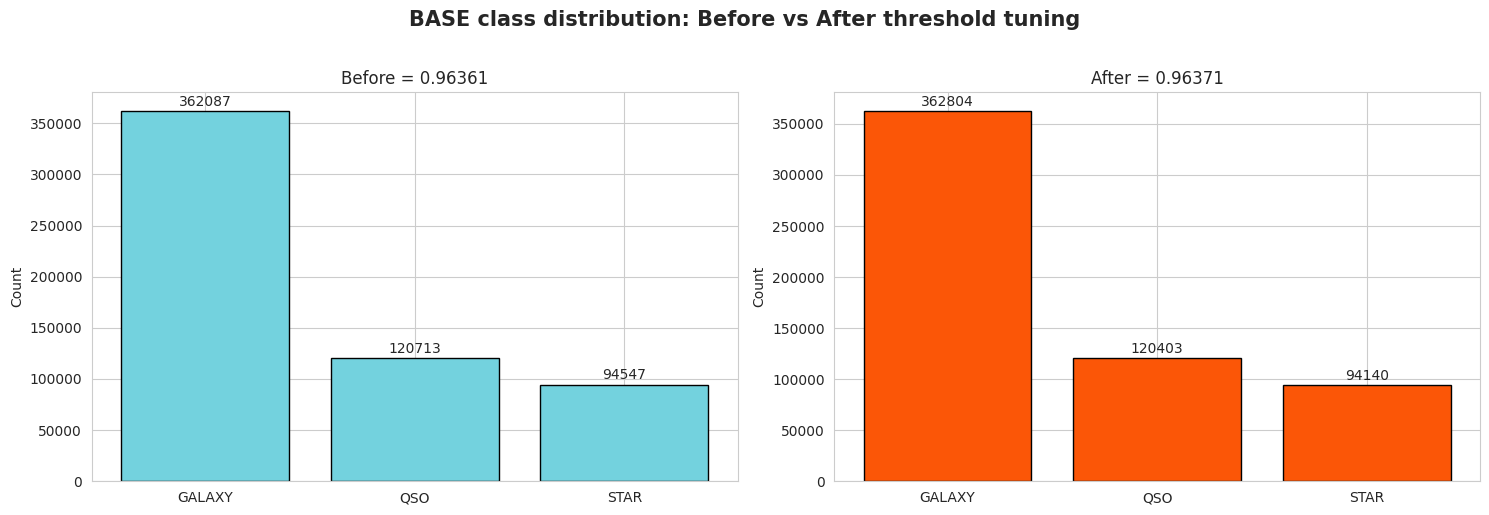

oof__test files saved as: oof_base_logit_optim_96371.npy test_base_logit_optim_96371.npy
Submission file saved as: submit_base_logit_optim_96371.csv


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [62]:
log_oof  = base_stack_oof.to_numpy()
log_test = base_stack_test.to_numpy()

base_scipy_weights, base_scipy_score = tune_weights_scipy(log_oof, train[TARGET].to_numpy())

# print(f"Baseline (argmax): {baseline_score:.5f}")
get_stack_score = [i for i in base_stack_score.values()][0]

print('-'*50, f'{CFG['YELLOW']}')
print(f"Stacking  Score:   {get_stack_score:.5f}")
print(f"Optimized Score:   {base_scipy_score:.5f}")
print(f"Improved  Score:   {base_scipy_score - get_stack_score:.5f}")
print(f"{CFG['RESET']}{'-'*50}")

print(f"""Best weights *****
GALAXY: {base_scipy_weights[0]:.4f},
QSO: {base_scipy_weights[1]:.4f},
STAR: {base_scipy_weights[2]:.4f}
""")

## -- APPLY WEIGHTS TO LOGISTIC PREDICTIONS --
oof_log_raw = np.argmax(log_oof, axis=1)
test_log_raw = np.argmax(log_test, axis=1)

oof_optimized  = np.argmax(log_oof * base_scipy_weights, axis=1)
test_optimized = np.argmax(log_test * base_scipy_weights, axis=1)

## -- Visualize Differences --
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], oof_log_raw, f'Before = {get_stack_score:.5f}', '#73D2DE'),
    (axes[1], oof_optimized, f'After = {base_scipy_score:.5f}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(log_oof.shape[1])]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')

    for i, c in enumerate(counts):
        ax.text(i, c + 5000, str(c), ha='center', fontsize=10)

plt.suptitle('BASE class distribution: Before vs After threshold tuning',
             fontsize=15, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.show()

## -- Base stack submission --
sc = f'{base_scipy_score:.5f}'.split('.')[1]
n_oof  = f'oof_base_logit_optim_{sc}.npy'
n_pred = f'test_base_logit_optim_{sc}.npy'

np.save(n_oof, oof_optimized)
np.save(n_pred, test_optimized)
print('oof__test files saved as:', n_oof, n_pred)

sub = f"submit_base_logit_optim_{sc}.csv"
submit[TARGET] = pd.Series(test_optimized).map(r_mapping)
submit.to_csv(sub, index=False)
print('Submission file saved as:', sub)

submit.head(10)

Optimization terminated successfully.
         Current function value: -0.963672
         Iterations: 24
         Function evaluations: 63
Optimization terminated successfully.
         Current function value: -0.963622
         Iterations: 29
         Function evaluations: 79
Optimization terminated successfully.
         Current function value: -0.963650
         Iterations: 43
         Function evaluations: 97
Optimization terminated successfully.
         Current function value: -0.963659
         Iterations: 39
         Function evaluations: 92
Optimization terminated successfully.
         Current function value: -0.963315
         Iterations: 44
         Function evaluations: 102
Optimization terminated successfully.
         Current function value: -0.963672
         Iterations: 49
         Function evaluations: 112
--------------------------------------------------
Stacking  Score:   0.96359
Optimized Score:   0.96367
Improve   Score:   0.00008
--------------------------------

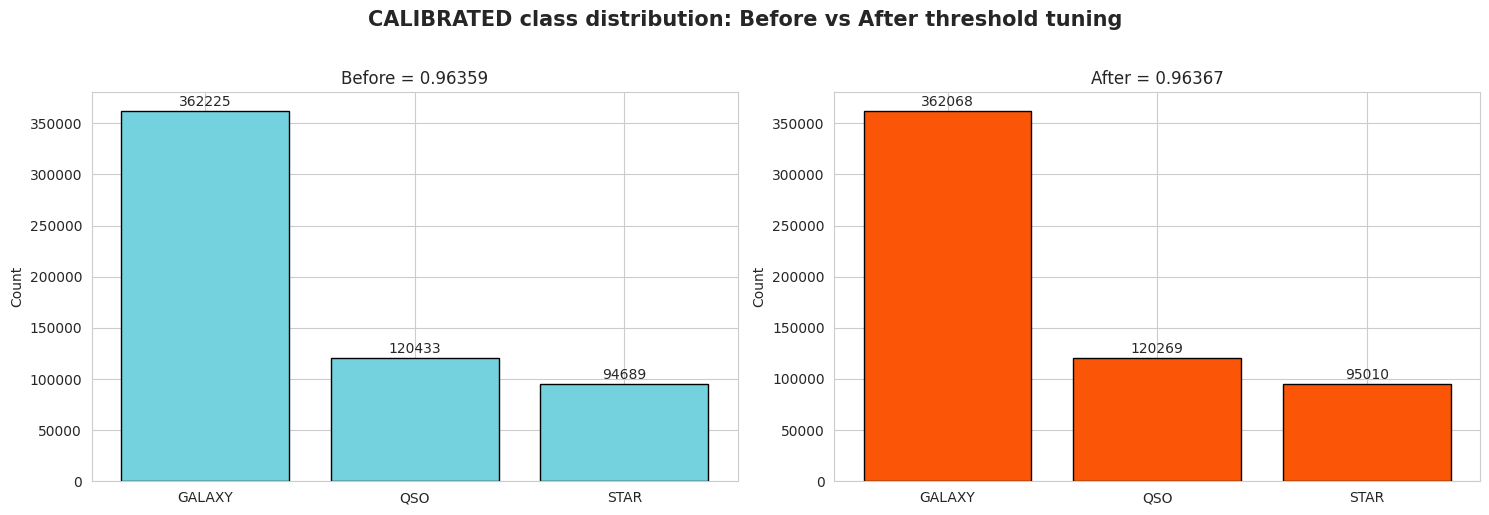

oof__test files saved as: oof_calib_logit_optim_96367.npy test_calib_logit_optim_96367.npy
Submission file saved as: submit_calib_logit_optim_96367.csv


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [63]:
calib_log_oof  = calib_stack_oof.to_numpy()
calib_log_test = calib_stack_test.to_numpy()

calib_scipy_weights, calib_scipy_score = tune_weights_scipy(calib_log_oof, train[TARGET].to_numpy())

# print(f"Baseline (argmax): {baseline_score:.5f}")
get_stack_score2 = [i for i in calib_stack_score.values()][0]

print(f"{'-'*50}{CFG['YELLOW']}")
print(f"Stacking  Score:   {get_stack_score2:.5f}")
print(f"Optimized Score:   {calib_scipy_score:.5f}")
print(f"Improve   Score:   {calib_scipy_score - get_stack_score2:.5f}")
print(f"{CFG['RESET']}{'-'*50}")

print(f"""Best weights *****
GALAXY: {calib_scipy_weights[0]:.4f},
QSO: {calib_scipy_weights[1]:.4f},
STAR: {calib_scipy_weights[2]:.4f}
""")

## -- APPLY WEIGHTS TO LOGISTIC PREDICTIONS --
calib_oof_log_raw  = np.argmax(calib_log_oof, axis=1)
calib_test_log_raw = np.argmax(calib_log_test, axis=1)

calib_oof_optimized  = np.argmax(calib_log_oof * calib_scipy_weights, axis=1)
calib_test_optimized = np.argmax(calib_log_test * calib_scipy_weights, axis=1)

## -- Visualize Differences --
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], calib_oof_log_raw, f'Before = {get_stack_score2:.5f}', '#73D2DE'),
    (axes[1], calib_oof_optimized, f'After = {calib_scipy_score:.5f}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(calib_log_oof.shape[1])]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')
    
    for i, c in enumerate(counts):
        ax.text(i, c + 5000, str(c), ha='center', fontsize=10)

plt.suptitle('CALIBRATED class distribution: Before vs After threshold tuning',
             fontsize=15, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.show()

## -- Calibrated stack submission --
sc = f'{calib_scipy_score:.5f}'.split('.')[1]
n_oof  = f'oof_calib_logit_optim_{sc}.npy'
n_pred = f'test_calib_logit_optim_{sc}.npy'

np.save(n_oof, calib_oof_optimized)
np.save(n_pred, calib_test_optimized)
print('oof__test files saved as:', n_oof, n_pred)

sub = f"submit_calib_logit_optim_{sc}.csv"
submit[TARGET] = pd.Series(calib_test_optimized).map(r_mapping)
submit.to_csv(sub, index=False)
print('Submission file saved as:', sub)

submit.head(10)